<font color='green' size='7'>**Итоговая аттестация**</font>  
<font size='6' color='#11a642'>**Задание:**</font>  

Итоговая аттестация основана на конкурсе:  
[https://www.kaggle.com/competitions/playground-series-s5e7/overview](https://www.kaggle.com/competitions/playground-series-s5e7/overview).  

<font size='4' color='#11a642'>**Ваша задача:**</font> Построить модель с лучшими метриками.  
<font size='4' color='#11a642'>**Что можно использовать:**</font> Любые модели и методы обработки данных.  
<font size='4' color='#11a642'>**Сколько моделей нужно построить:**</font> Столько, сколько вы считаете достаточным для обоснования выбора наилучшей модели.  
<font size='4' color='#11a642'>**Важно:**</font> Каждый этап должен сопровождаться комментариями и выводами.  

<font size='4' color='green'>**Рекомендованные этапы:**</font>  
- Провести EDA.  
- Выявить и обработать проблемы в данных (если это улучшит метрики).  
- Построить несколько моделей с разными подходами.  
- Выбрать наилучшую модель.  
- *Опционально:* Участие в Kaggle (загрузить решение и указать позицию в leaderboard).  

На момент выдачи задания конкурс активен, поэтому у вас есть возможность не только выполнить учебную задачу, но и поучаствовать в соревновании.  

<font size='4' color='green'>**Форма сдачи:**</font>  
- Файл в формате `.ipynb` (Jupyter Notebook).  
- Перед загрузкой убедитесь, что ноутбук запускается без ошибок (`Kernel → Restart & Run All`).  

Удачи в выполнении задания!  

# <font color='#11a642' size='6'> **Импорт и установка библиотек**

In [1]:
# Импорт и установка библиотек

import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
import optuna
import shap
from sklearn.inspection import permutation_importance

c:\Users\Maks\Documents\Курс\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# <font color='#11a642' size='6'> **Загрузка данных**

In [2]:
def load_dataset() -> pd.DataFrame:
  '''
  Функция скачивает данные с сайта kaggle
  return:
      - pd.DataFrame

  '''
  
  !kaggle competitions download -c playground-series-s5e7
  
  # распаковка архива
  zip_ref = zipfile.ZipFile('playground-series-s5e7.zip', 'r')
  zip_ref.extractall()
  zip_ref.close()
  df_train = pd.read_csv('train.csv')
  df_test = pd.read_csv('test.csv')
  df_sample_submission = pd.read_csv('sample_submission.csv')
  return df_train, df_test, df_sample_submission

In [3]:
df_train, df_test, df_sample_submission = load_dataset()

playground-series-s5e7.zip: Skipping, found more recently modified local copy (use --force to force download)


Описание признаков

- Time_spent_Alone: Количество часов, проведённых в одиночестве ежедневно (0–11) (0–11).

- Stage_fear: Наличие страха сцены (Yes/No).

- Social_event_attendance: Частота посещения социальных мероприятий (0–10).

- Going_outside: Частота выхода на улицу (0–7).

- Drained_after_socializing: Чувство опустошения после общения (Yes/No).

- Friends_circle_size: Количество близких друзей (0–15).

- Post_frequency: Частота публикаций в социальных сетях  (0–10).

- Personality: Целевая переменная (Extrovert/Introvert).*

# <font color='#11a642' size='6'> **Разведочный анализ данных**

In [4]:
df_train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [5]:
# Приведем названия столбцов к нижнему регистру
df_train.columns = (col.lower() for col in df_train.columns)

df_test.columns = (col.lower() for col in df_test.columns)

Добавим в тренировочную и тестовую выборку еще два признака:

- Индекс социальной активности - показывает общий уровень вовлеченности человека в социальную жизнь

- Коэффициент социальной мобильности - демонстрирует потенциал расширения социальных связей

In [6]:
df_train['social_activity'] = (df_train['going_outside'] + df_train['social_event_attendance']) / 2
df_train['social_mobility'] = (df_train['social_event_attendance'] + df_train['going_outside']) * df_train['friends_circle_size']

df_test['social_activity'] = (df_test['going_outside'] + df_test['social_event_attendance']) / 2
df_test['social_mobility'] = (df_test['social_event_attendance'] + df_test['going_outside']) * df_test['friends_circle_size']

In [7]:
df_train.head()

,id,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality,social_activity,social_mobility
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert,5.0,150.0
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert,5.0,100.0
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert,0.5,3.0
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert,5.0,110.0
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert,4.0,104.0


In [8]:
# Определим целевую переменную

target = 'personality'

Проанализируем целевую переменную

In [9]:
df_train[target].unique()

array(['Extrovert', 'Introvert'], dtype=object)

Видим, что целевая переменная принимает всего два значения, значит это задача бинарной классификации. Для ее решения построим несколько моделей (логистическую регрессию, дерево решений, Random Forest, XGBoost, CatBoost, LightGBM) и выберем лучшую на основе метрик.

In [10]:
# Для обучения модели необходимо целевую переменную закодировать в число
dict_personality = {'Extrovert':0, 'Introvert':1}
df_train['int_personality'] = df_train['personality'].map(dict_personality)
target = 'int_personality'

In [11]:
df_train.head()

,id,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality,social_activity,social_mobility,int_personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert,5.0,150.0,0
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert,5.0,100.0,0
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert,0.5,3.0,1
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert,5.0,110.0,0
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert,4.0,104.0,0


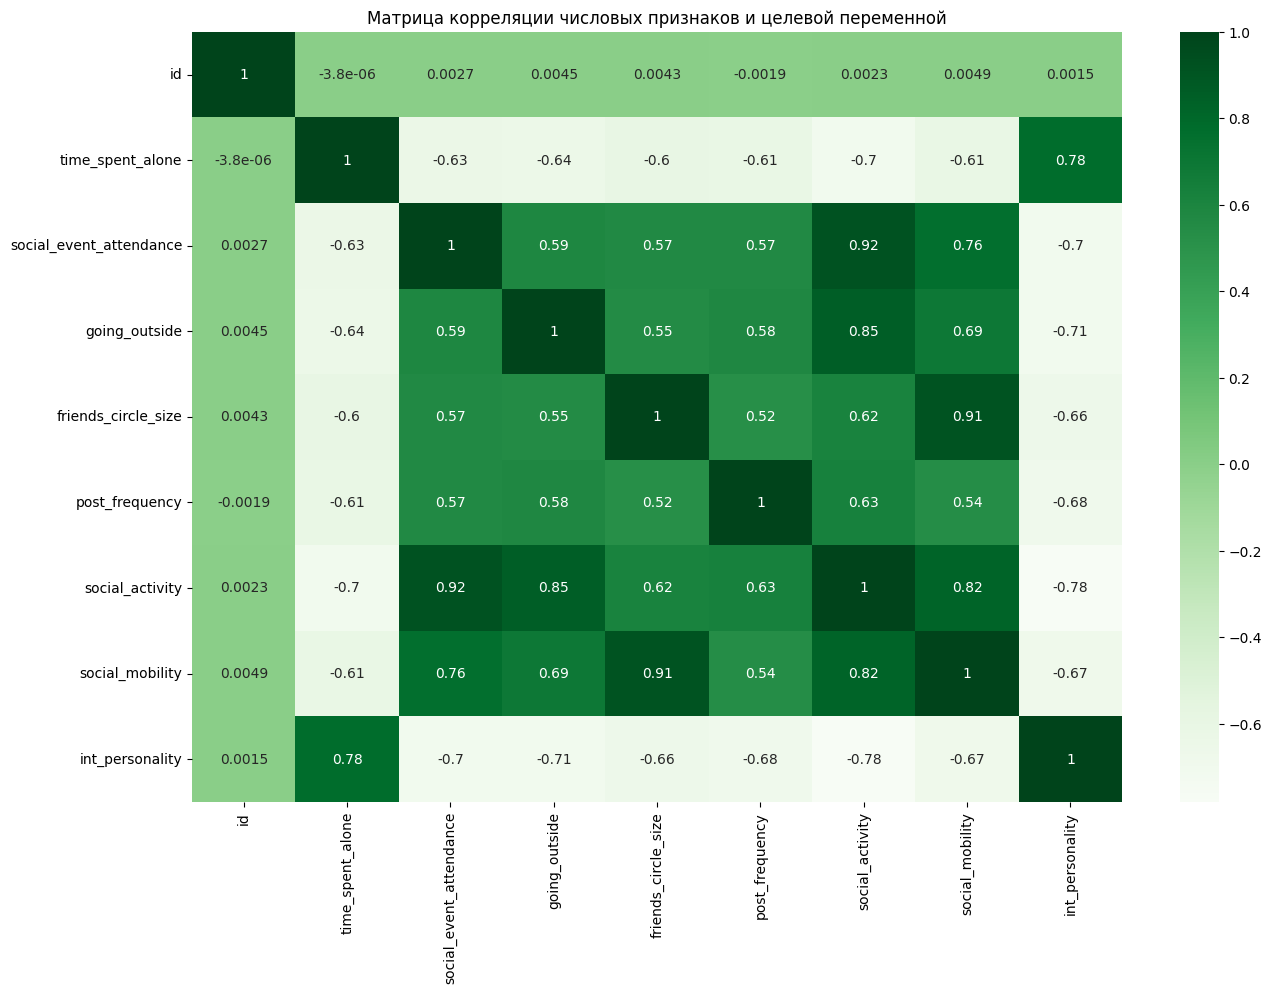

In [12]:
# Посторим тепловую карту линейной корреляции числовых признаков и целевой переменной
plt.figure(figsize=(15, 10))
sns.heatmap(df_train.drop(['stage_fear', 'drained_after_socializing', 'personality'], axis=1).corr(), annot=True, cmap="Greens")
plt.title('Матрица корреляции числовых признаков и целевой переменной')
plt.show()

Из графика видно, что id не оказывает никакого влияния на целевой признак, поэтому этот признак мы исключим

In [13]:
# Проверим есть ли пропуски в нашем датасете
df_train.isna().sum()

id                              0
time_spent_alone             1190
stage_fear                   1893
social_event_attendance      1180
going_outside                1466
drained_after_socializing    1149
friends_circle_size          1054
post_frequency               1264
personality                     0
social_activity              2595
social_mobility              3555
int_personality                 0
dtype: int64

Как видим, пропусков довольно много. придется их обрабатывать впоследствии

In [14]:
# Разделение признаков и целевой переменной
X = df_train.drop(['id', 'personality', target], axis=1)
y = df_train[target]

In [15]:
# Определяем категориальные и числовые признаки
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(include=np.number).columns
print('Категориальные признаки:', list(cat_features))
print('Числовые признаки:', list(num_features))

Категориальные признаки: ['stage_fear', 'drained_after_socializing']
Числовые признаки: ['time_spent_alone', 'social_event_attendance', 'going_outside', 'friends_circle_size', 'post_frequency', 'social_activity', 'social_mobility']


Анализ числовых признаков

In [16]:
# Минимум (min), максимум (max), среднее (mean), медиана (50%) для всех признаков

print(X[num_features].describe().loc[['mean', 'min', 'max', '50%']])

      time_spent_alone  social_event_attendance  going_outside  \
mean          3.137764                 5.265106       4.044319   
min           0.000000                 0.000000       0.000000   
max          11.000000                10.000000       7.000000   
50%           2.000000                 5.000000       4.000000   

      friends_circle_size  post_frequency  social_activity  social_mobility  
mean             7.996737        4.982097          4.69725        87.410248  
min              0.000000        0.000000          0.00000         0.000000  
max             15.000000       10.000000          8.50000       255.000000  
50%              8.000000        5.000000          5.00000        90.000000  


Анализ категориальных признаков

In [17]:
# Мода, количество уникальных значений для категориальных признаков

df_mode = X[cat_features].mode()
df_unique = X[cat_features].nunique()
print("Мода:")
print(df_mode)
print("-" * 50)
print('Количество уникальных значений')
print(df_unique)

Мода:
  stage_fear drained_after_socializing
0         No                        No
--------------------------------------------------
Количество уникальных значений
stage_fear                   2
drained_after_socializing    2
dtype: int64


Как видим, уникальных значений не так уж и много. Тоже их обработаем впоследствии

In [18]:
X['stage_fear'].unique()

array(['No', 'Yes', nan], dtype=object)

In [19]:
X['drained_after_socializing'].unique()

array(['No', nan, 'Yes'], dtype=object)

Анализ целевой переменной

In [20]:
# Доля 1
y.value_counts(normalize=True)


int_personality
0    0.739527
1    0.260473
Name: proportion, dtype: float64

In [21]:
# Выведем в процентном соотношении долю 1 в целевой переменной
proportion_1 = (y == 1).mean() * 100
print(f'Доля 1 составляет: {proportion_1:.2f} %')

Доля 1 составляет: 26.05 %


Посмотрим, есть ли выбросы

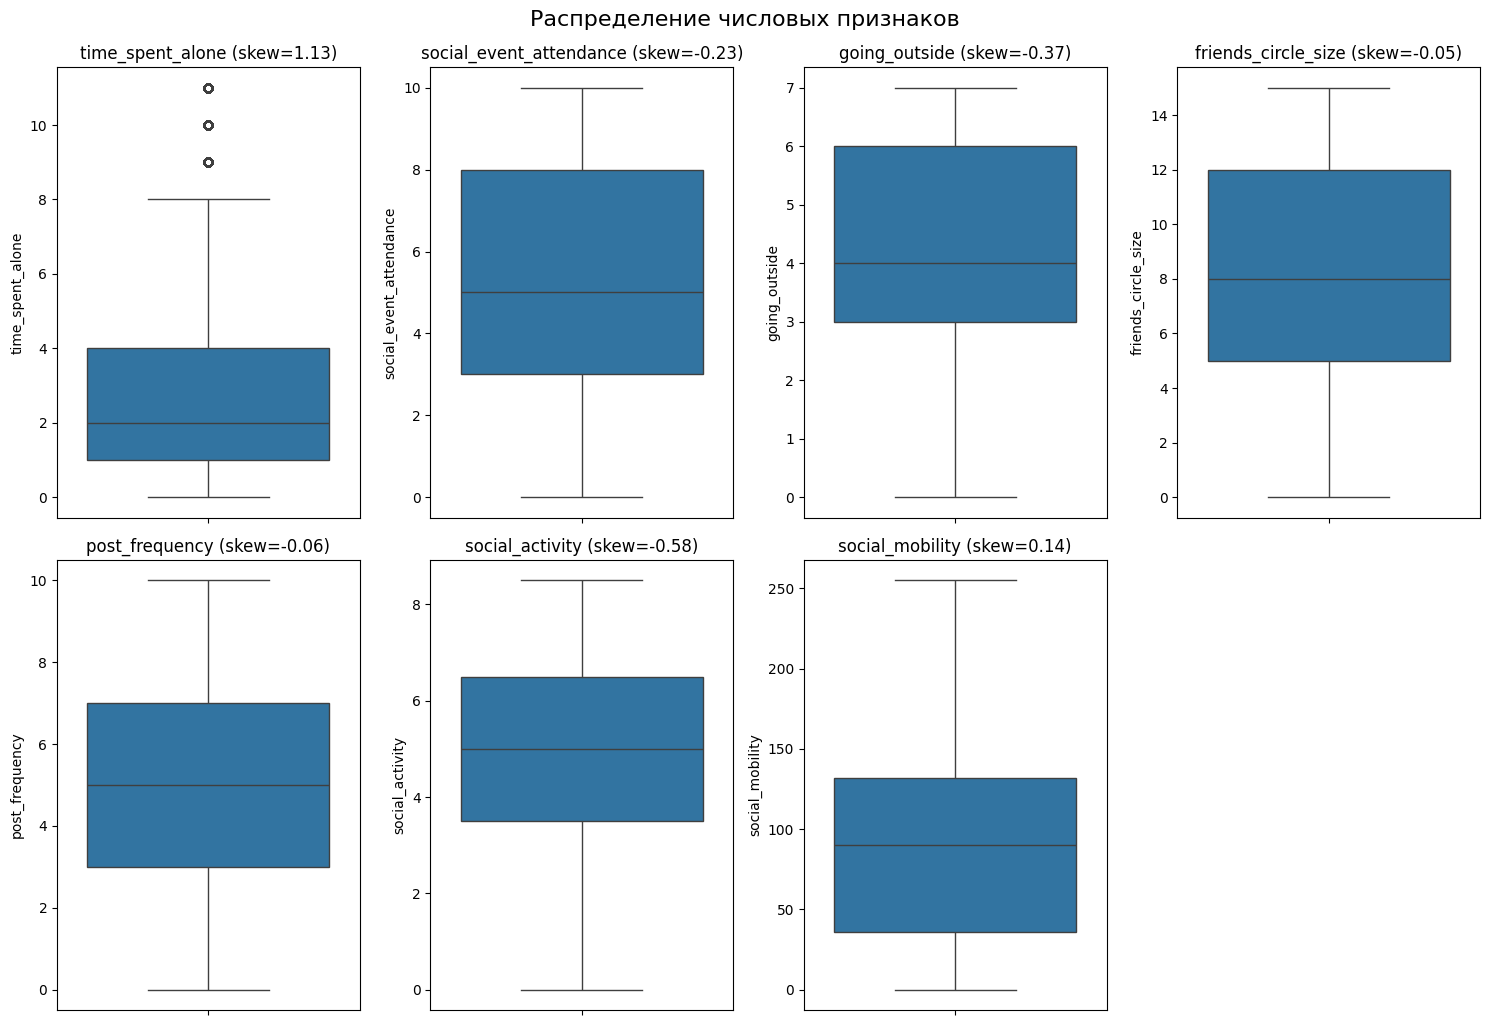

In [22]:
# Визуализация выбросов с помощью boxplot

plt.figure(figsize=(15, 10))
n_cols = len(num_features) // 3
n_rows = 3 if len(num_features) % 3 == 0 else 4
for i, col in enumerate(num_features):
    plt.subplot(n_cols, n_rows, i + 1)
    sns.boxplot(df_train[col])
    plt.title(f'{col} (skew={df_train[col].skew():.2f})')
plt.tight_layout()
plt.suptitle("Распределение числовых признаков", fontsize=16, y=1.02)
plt.show()

Как видно на графиках, все выбросы укладываются в нормальные значения, поэтому обрабатывать выбросы мы не будем

Разделим данные на трейн и тест

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify=y,
                                                    train_size=0.7,
                                                    random_state=42)

# <font color='#11a642' size='6'> **Подготовка данных к обучению**

Обработаем категориальные признаки: пропуски обработаем с помощью TargetEncoder и заполним их самым частым значением.
Пропуски в числовых признаках обработаем через SimpleImputer и заполним средним значением, а также стандартизируем с помощью StandartScaler. И для всего этого создадим Pipeline

In [24]:
# Обработка категориальных признаков
cat_pipe = Pipeline(
    [

        (
            'enc',
            TargetEncoder(cols = cat_features)

         ),
        (
            'imputer',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),

    ]
)

In [25]:
# Обработка числовых признаков
num_pipe = Pipeline(
    [
        (
            'scaler',
            StandardScaler()
        ),
        (
            'imputer',
            SimpleImputer(missing_values=np.nan, strategy='mean')
        ),

    ]
)

In [26]:
# Создадим препроцессор
data_preprocessor = ColumnTransformer(
    [
        ('cat', cat_pipe, cat_features),
        ('num', num_pipe, num_features),
    ],
    remainder='passthrough'
)

In [27]:
type(data_preprocessor.fit_transform(X_train, y_train))

numpy.ndarray

In [28]:
data_preprocessor.get_feature_names_out()

array(['cat__stage_fear', 'cat__drained_after_socializing',
       'num__time_spent_alone', 'num__social_event_attendance',
       'num__going_outside', 'num__friends_circle_size',
       'num__post_frequency', 'num__social_activity',
       'num__social_mobility'], dtype=object)

In [29]:
X_train_p = pd.DataFrame(
    data_preprocessor.fit_transform(X_train, y_train),
    columns=data_preprocessor.get_feature_names_out()
)

X_test_p = pd.DataFrame(
    data_preprocessor.transform(X_test),
    columns=data_preprocessor.get_feature_names_out()
)

In [30]:
X_train_p.head()

,cat__stage_fear,cat__drained_after_socializing,num__time_spent_alone,num__social_event_attendance,num__going_outside,num__friends_circle_size,num__post_frequency,num__social_activity,num__social_mobility
0,0.024921,0.024422,-0.043138,1.351796,-0.507072,1.418848,1.052463,0.607105,1.350453
1,0.939793,0.942998,2.288715,-1.915963,-0.993869,-1.893739,-0.688070,-1.734681,-1.476157
2,0.939793,0.595178,1.622471,-0.826710,-1.967463,-0.947286,-1.036177,-1.500503,-1.274257
3,0.024921,0.024422,-1.042504,0.988711,1.440116,1.182235,1.400570,1.309641,1.804729
4,0.389932,0.942998,2.288715,-0.826710,-0.993869,-0.710673,-1.036177,-1.032145,-1.055531


In [31]:
X_test_p.head()

,cat__stage_fear,cat__drained_after_socializing,num__time_spent_alone,num__social_event_attendance,num__going_outside,num__friends_circle_size,num__post_frequency,num__social_activity,num__social_mobility
0,0.024921,0.024422,-4.201092e-17,9.887114e-01,-0.020275,-0.474059,7.043564e-01,6.071049e-01,-2.647530e-01
1,0.024921,0.024422,-1.042504e+00,-1.005414e-01,0.466522,0.945621,-1.503546e-16,1.387476e-01,5.428498e-01
2,0.024921,0.024422,-7.093819e-01,9.887114e-01,0.466522,-0.947286,1.400570e+00,8.412835e-01,-6.012542e-01
3,0.389932,0.024422,-3.762600e-01,-4.636256e-01,-0.507072,-0.000832,3.562497e-01,-5.637882e-01,-5.339540e-01
4,0.939793,0.942998,1.289349e+00,5.028528e-17,-1.967463,-1.420513,-6.880704e-01,-2.096015e-16,2.339542e-17


Обработаем также данные и в тестовом файле для применения в обученных моделях

In [32]:
type(data_preprocessor.transform(df_test))

numpy.ndarray

In [33]:
df_test_p = data_preprocessor.transform(df_test)

In [34]:
df_test = pd.DataFrame(df_test_p, columns=data_preprocessor.get_feature_names_out(), index=df_test.index)

# <font color='#11a642' size='6'> **Построение моделей**

## <font color='blue' size='5'> **Логистическая регрессия**

In [35]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    max_iter = trial.suggest_int('max_iter', 10, 10000)
    C = trial.suggest_int('C', 1, 100)
    solver = trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'])

    # Создание модели
    model_log_reg = LogisticRegression(
        C = C,
        solver = solver,
        max_iter = max_iter,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_log_reg, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_log_reg = optuna.create_study(direction='maximize')
study_log_reg.optimize(objective, n_trials=50)

# Лучший результат
print("Лучший результат:")
trial_log_reg = study_log_reg.best_trial

print(f"  Accuracy: {trial_log_reg.value}")
best_params_log_reg = {}

print("Лучшие гиперпараметры:")
for key, value in trial_log_reg.params.items():
    best_params_log_reg[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:13:49,660] A new study created in memory with name: no-name-2c37c20e-569d-44b7-9a25-66879b3e3835
[I 2025-07-31 11:13:50,311] Trial 0 finished with value: 0.9680704321967601 and parameters: {'max_iter': 1200, 'C': 35, 'solver': 'newton-cg'}. Best is trial 0 with value: 0.9680704321967601.
[I 2025-07-31 11:13:50,815] Trial 1 finished with value: 0.9680704321967601 and parameters: {'max_iter': 1923, 'C': 35, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9680704321967601.
[I 2025-07-31 11:13:51,157] Trial 2 finished with value: 0.9680704321967601 and parameters: {'max_iter': 945, 'C': 21, 'solver': 'newton-cg'}. Best is trial 0 with value: 0.9680704321967601.
[I 2025-07-31 11:13:51,550] Trial 3 finished with value: 0.9680704321967601 and parameters: {'max_iter': 2309, 'C': 66, 'solver': 'newton-cg'}. Best is trial 0 with value: 0.9680704321967601.
[I 2025-07-31 11:13:52,135] Trial 4 finished with value: 0.9680704321967601 and parameters: {'max_iter': 5315, 'C': 4, 

Лучший результат:
  Accuracy: 0.9680704321967601
Лучшие гиперпараметры:
  max_iter: 1200
  C: 35
  solver: newton-cg


In [36]:
# Обучим модель с наилучшими праметрами

model_log_reg_best = LogisticRegression(**best_params_log_reg)
model_log_reg_best.fit(X_train_p, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,35
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,1200
,multi_class,'deprecated'


In [37]:
# Получение вероятностей логистической регрессии
y_train_proba_lr = model_log_reg_best.predict_proba(X_train_p)[:, 1]
y_test_proba_lr = model_log_reg_best.predict_proba(X_test_p)[:, 1]
y_pred_lr = model_log_reg_best.predict(X_test_p)

In [38]:
# Вычисление метрик логистической регрессии
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, model_log_reg_best.predict_proba(X_test_p)[:, 1])

# Вывод результатов
print(f'Accuracy логистической регрессии: {accuracy_lr}')
print(f'Precision логистической регрессии: {precision_lr:.5f}')
print(f'Recall логистической регрессии: {recall_lr:.5f}')
print(f'F1-score логистической регрессии: {f1_lr:.5f}')
print(f'ROC-AUC логистической регрессии: {roc_auc_lr:.5f}')

Accuracy логистической регрессии: 0.9715725080964376
Precision логистической регрессии: 0.94730
Recall логистической регрессии: 0.94337
F1-score логистической регрессии: 0.94533
ROC-AUC логистической регрессии: 0.96070


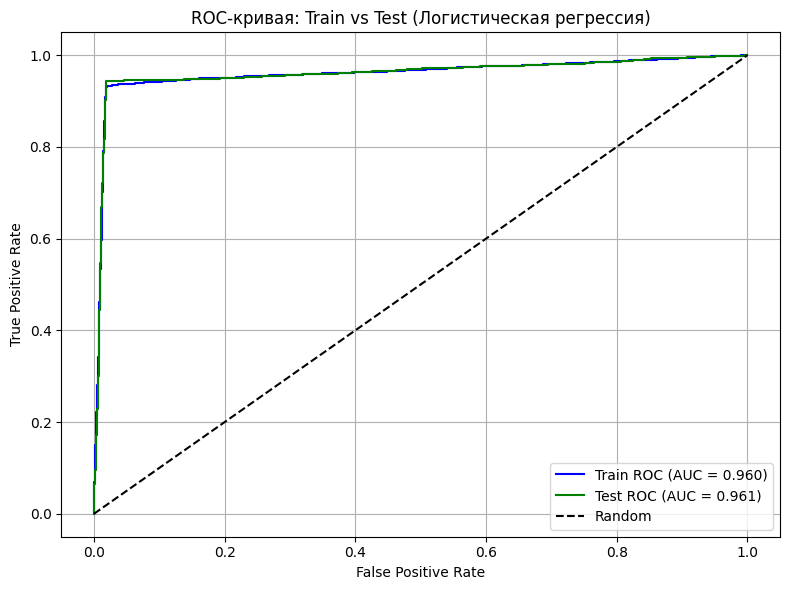

In [39]:
# ROC-кривая + AUC логистической регрессии
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_lr)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_lr)

auc_train = roc_auc_score(y_train, y_train_proba_lr)
auc_test = roc_auc_score(y_test, y_test_proba_lr)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Логистическая регрессия)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## <font color='blue' size='5'> **Дерево решений**

In [40]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 10, 50)
    ccp_alpha = trial.suggest_float('ccp_alpha', 0.01, 2.0)

    # Создание модели
    model_dt = DecisionTreeClassifier(
        max_depth = max_depth,
        min_samples_leaf = min_samples_leaf,
        ccp_alpha = ccp_alpha,
        min_samples_split=min_samples_split,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_dt, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective, n_trials=50)

# Лучший результат
print("Лучший результат:")
trial_dt = study_dt.best_trial

print(f"  Accuracy: {trial_dt.value}")
best_params_dt = {}

print("Лучшие гиперпараметры:")
for key, value in trial_dt.params.items():
    best_params_dt[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:14:13,627] A new study created in memory with name: no-name-4eaef22a-b452-4a9a-b3e8-a03fe046cf4a
[I 2025-07-31 11:14:14,183] Trial 0 finished with value: 0.73954960288375 and parameters: {'min_samples_split': 20, 'max_depth': 45, 'min_samples_leaf': 12, 'ccp_alpha': 1.1553682882772773}. Best is trial 0 with value: 0.73954960288375.
[I 2025-07-31 11:14:14,607] Trial 1 finished with value: 0.9453187381601792 and parameters: {'min_samples_split': 14, 'max_depth': 35, 'min_samples_leaf': 14, 'ccp_alpha': 0.10784665713713111}. Best is trial 1 with value: 0.9453187381601792.
[I 2025-07-31 11:14:14,850] Trial 2 finished with value: 0.73954960288375 and parameters: {'min_samples_split': 11, 'max_depth': 48, 'min_samples_leaf': 38, 'ccp_alpha': 1.3673914232696478}. Best is trial 1 with value: 0.9453187381601792.
[I 2025-07-31 11:14:15,085] Trial 3 finished with value: 0.73954960288375 and parameters: {'min_samples_split': 20, 'max_depth': 50, 'min_samples_leaf': 40, 'ccp_alpha'

Лучший результат:
  Accuracy: 0.9666821978751285
Лучшие гиперпараметры:
  min_samples_split: 7
  max_depth: 44
  min_samples_leaf: 43
  ccp_alpha: 0.020634168369216374


In [41]:
# Обучим модель с наилучшими праметрами

model_dt_best = DecisionTreeClassifier(**best_params_dt)
model_dt_best.fit(X_train_p, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,44
,min_samples_split,7
,min_samples_leaf,43
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
# Получение вероятностей дерева решений
y_train_proba_dt = model_dt_best.predict_proba(X_train_p)[:, 1]
y_test_proba_dt = model_dt_best.predict_proba(X_test_p)[:, 1]
y_pred_dt = model_dt_best.predict(X_test_p)

In [43]:
# Вычисление метрик дерева решений
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, model_dt_best.predict_proba(X_test_p)[:, 1])

# Вывод результатов
print(f'Accuracy дерева решений: {accuracy_dt}')
print(f'Precision дерева решений: {precision_dt:.5f}')
print(f'Recall дерева решений: {recall_dt:.5f}')
print(f'F1-score дерева решений: {f1_dt:.5f}')
print(f'ROC-AUC дерева решений: {roc_auc_dt:.5f}')


Accuracy дерева решений: 0.9708528247571069
Precision дерева решений: 0.94653
Recall дерева решений: 0.94130
F1-score дерева решений: 0.94391
ROC-AUC дерева решений: 0.96062


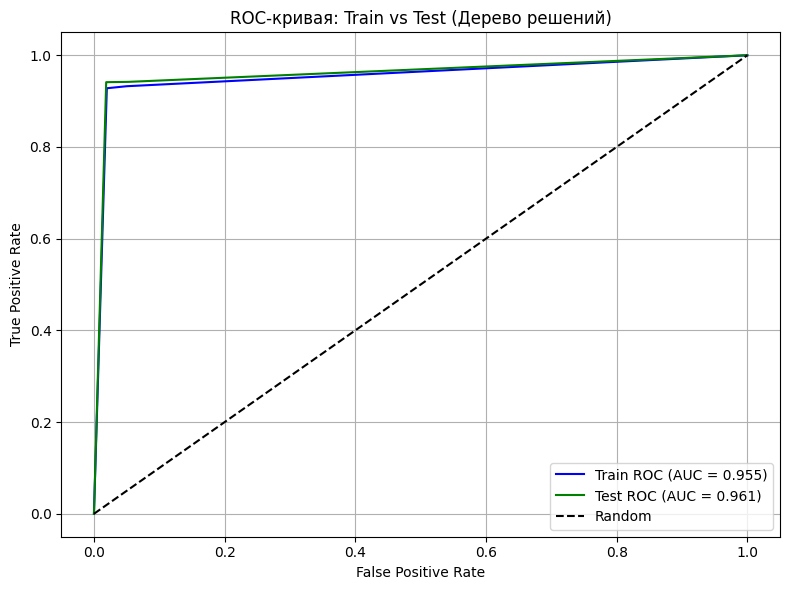

In [44]:
# ROC-кривая + AUC дерева решений
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_dt)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_dt)

auc_train = roc_auc_score(y_train, y_train_proba_dt)
auc_test = roc_auc_score(y_test, y_test_proba_dt)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Дерево решений)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## <font color='blue' size='5'> **Random Forest**

In [45]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    n_estimators = trial.suggest_int('n_estimators', 2, 500)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 10, 100)

    # Создание модели
    model_rf = RandomForestClassifier(
        max_depth = max_depth,
        min_samples_leaf = min_samples_leaf,
        n_estimators = n_estimators,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_rf, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective, n_trials=50)

# Лучший результат
print("Лучший результат:")
trial_rf = study_rf.best_trial

print(f"  Accuracy: {trial_rf.value}")
best_params_rf = {}

print("Лучшие гиперпараметры:")
for key, value in trial_rf.params.items():
    best_params_rf[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:14:33,880] A new study created in memory with name: no-name-42a4abe8-c5b9-467a-b5d9-7a51c853c0f7
[I 2025-07-31 11:14:42,559] Trial 0 finished with value: 0.967761909250366 and parameters: {'n_estimators': 91, 'max_depth': 48, 'min_samples_leaf': 92}. Best is trial 0 with value: 0.967761909250366.
[I 2025-07-31 11:14:56,708] Trial 1 finished with value: 0.9679161707235631 and parameters: {'n_estimators': 159, 'max_depth': 50, 'min_samples_leaf': 43}. Best is trial 1 with value: 0.9679161707235631.
[I 2025-07-31 11:15:31,188] Trial 2 finished with value: 0.9678390399869645 and parameters: {'n_estimators': 404, 'max_depth': 22, 'min_samples_leaf': 52}. Best is trial 1 with value: 0.9679161707235631.
[I 2025-07-31 11:15:37,555] Trial 3 finished with value: 0.96783906972125 and parameters: {'n_estimators': 76, 'max_depth': 22, 'min_samples_leaf': 81}. Best is trial 1 with value: 0.9679161707235631.
[I 2025-07-31 11:15:46,931] Trial 4 finished with value: 0.9678390399869645 

Лучший результат:
  Accuracy: 0.9682246342013862
Лучшие гиперпараметры:
  n_estimators: 470
  max_depth: 48
  min_samples_leaf: 11


In [46]:
# Обучим модель с наилучшими праметрами

model_rf_best = RandomForestClassifier(**best_params_rf)
model_rf_best.fit(X_train_p, y_train)

,n_estimators,470
,criterion,'gini'
,max_depth,48
,min_samples_split,2
,min_samples_leaf,11
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Получение вероятностей модели Random Forest
y_train_proba_rf = model_rf_best.predict_proba(X_train_p)[:, 1]
y_test_proba_rf = model_rf_best.predict_proba(X_test_p)[:, 1]
y_pred_rf = model_rf_best.predict(X_test_p)

In [48]:
# Вычисление метрик модели Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, model_rf_best.predict_proba(X_test_p)[:, 1])


# Вывод результатов
print(f'Accuracy Random Forest: {accuracy_rf}')
print(f'Precision Random Forest: {precision_rf:.5f}')
print(f'Recall Random Forest: {recall_rf:.5f}')
print(f'F1-score Random Forest: {f1_rf:.5f}')
print(f'ROC-AUC Random Forest: {roc_auc_rf:.5f}')


Accuracy Random Forest: 0.9712126664267722
Precision Random Forest: 0.94475
Recall Random Forest: 0.94475
F1-score Random Forest: 0.94475
ROC-AUC Random Forest: 0.97123


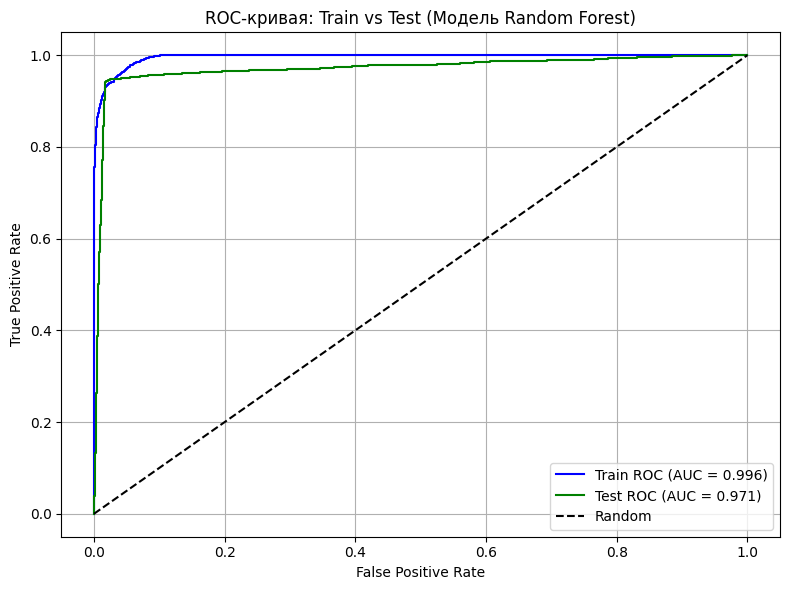

In [49]:
# ROC-кривая + AUC модели Random Forest
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_rf)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_rf)

auc_train = roc_auc_score(y_train, y_train_proba_rf)
auc_test = roc_auc_score(y_test, y_test_proba_rf)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Модель Random Forest)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## <font color='blue' size='5'> **XGBoost**

In [50]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    min_child_weight = trial.suggest_int('min_child_weight', 2, 30)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 2.0)

    # Создание модели
    model_xgb = XGBClassifier(
        max_depth = max_depth,
        min_child_weight = min_child_weight,
        learning_rate = learning_rate,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_xgb, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

# Лучший результат
print("# Лучший результат:")
trial_xgb = study_xgb.best_trial

print(f"  Accuracy: {trial_xgb.value}")
best_params_xgb = {}

print("Лучшие гиперпараметры:")
for key, value in trial_xgb.params.items():
    best_params_xgb[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:39:02,521] A new study created in memory with name: no-name-b90b2b4b-ccfb-44f1-9a35-47533f1ab73f
[I 2025-07-31 11:39:05,537] Trial 0 finished with value: 0.9654480168866953 and parameters: {'min_child_weight': 9, 'max_depth': 40, 'learning_rate': 0.5816589860758149}. Best is trial 0 with value: 0.9654480168866953.
[I 2025-07-31 11:39:08,896] Trial 1 finished with value: 0.9636743072877841 and parameters: {'min_child_weight': 3, 'max_depth': 50, 'learning_rate': 0.32452229628371393}. Best is trial 0 with value: 0.9654480168866953.
[I 2025-07-31 11:39:10,185] Trial 2 finished with value: 0.9669135306163531 and parameters: {'min_child_weight': 17, 'max_depth': 18, 'learning_rate': 0.8557609814673927}. Best is trial 2 with value: 0.9669135306163531.
[I 2025-07-31 11:39:11,819] Trial 3 finished with value: 0.9666049779356735 and parameters: {'min_child_weight': 11, 'max_depth': 19, 'learning_rate': 0.7377623713436107}. Best is trial 2 with value: 0.9669135306163531.
[I 2025

# Лучший результат:
  Accuracy: 0.9686874186209773
Лучшие гиперпараметры:
  min_child_weight: 27
  max_depth: 31
  learning_rate: 0.2717986607709184


In [51]:
# Обучим модель с наилучшими праметрами

model_xgb_best = XGBClassifier(**best_params_xgb)
model_xgb_best.fit(X_train_p, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [52]:
# Получение вероятностей модели XGBoost
y_train_proba_xgb = model_xgb_best.predict_proba(X_train_p)[:, 1]
y_test_proba_xgb = model_xgb_best.predict_proba(X_test_p)[:, 1]
y_pred_xgb = model_xgb_best.predict(X_test_p)

In [53]:
# Вычисление метрик модели XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, model_xgb_best.predict_proba(X_test_p)[:, 1])

# Вывод результатов
print(f'Accuracy модели XGBoost: {accuracy_xgb}')
print(f'Precision модели XGBoost: {precision_xgb:.5f}')
print(f'Recall модели XGBoost: {recall_xgb:.5f}')
print(f'F1-score модели XGBoost: {f1_xgb:.5f}')
print(f'ROC-AUC модели XGBoost: {roc_auc_xgb:.5f}')

Accuracy модели XGBoost: 0.9708528247571069
Precision модели XGBoost: 0.94406
Recall модели XGBoost: 0.94406
F1-score модели XGBoost: 0.94406
ROC-AUC модели XGBoost: 0.97299


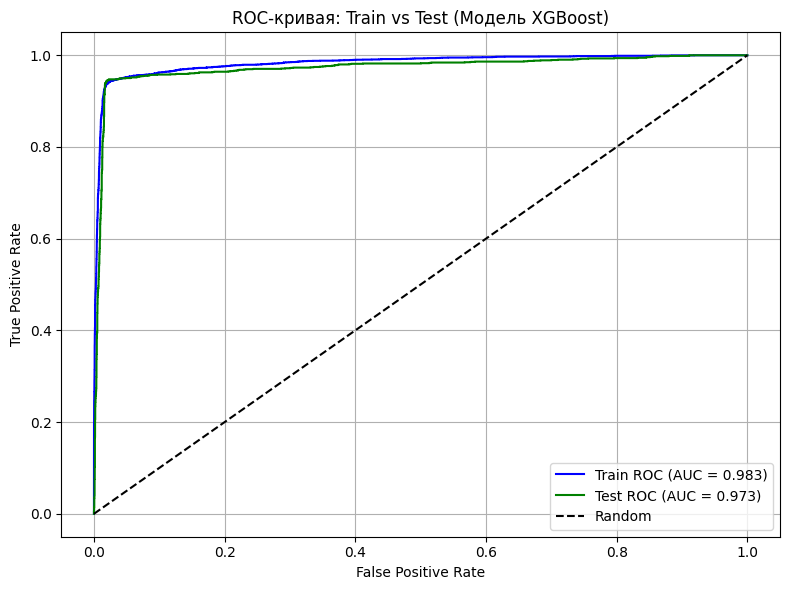

In [54]:
# ROC-кривая + AUC модели XGBoost
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_xgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_xgb)

auc_train = roc_auc_score(y_train, y_train_proba_xgb)
auc_test = roc_auc_score(y_test, y_test_proba_xgb)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Модель XGBoost)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## <font color='blue' size='5'> **CatBoost**

In [55]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    iterations = trial.suggest_int('iterations', 2, 20)
    depth = trial.suggest_int('depth', 2, 16)
    l2_leaf_reg = trial.suggest_int('l2_leaf_reg', 2, 50)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0)
    border_count = trial.suggest_int('border_count', 2, 20)

    # Создание модели
    model_cb = CatBoostClassifier(
        iterations = iterations,
        depth = depth,
        l2_leaf_reg = l2_leaf_reg,
        learning_rate = learning_rate,
        border_count = border_count,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_cb, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective, n_trials=50)

# Лучший результат
print("Лучший результат:")
trial_cb = study_cb.best_trial

print(f"  Accuracy: {trial_cb.value}")
best_params_cb = {}

print("Лучшие гиперпараметры:")
for key, value in trial_cb.params.items():
    best_params_cb[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:40:36,806] A new study created in memory with name: no-name-86c0c6ba-3c30-4afd-a758-04ff4095868e


0:	learn: 0.3444021	total: 452ms	remaining: 5.88s
1:	learn: 0.2374943	total: 464ms	remaining: 2.78s
2:	learn: 0.1813166	total: 468ms	remaining: 1.72s
3:	learn: 0.1593731	total: 543ms	remaining: 1.36s
4:	learn: 0.1479316	total: 611ms	remaining: 1.1s
5:	learn: 0.1406601	total: 635ms	remaining: 847ms
6:	learn: 0.1371794	total: 652ms	remaining: 652ms
7:	learn: 0.1341976	total: 659ms	remaining: 494ms
8:	learn: 0.1329705	total: 701ms	remaining: 389ms
9:	learn: 0.1320272	total: 744ms	remaining: 298ms
10:	learn: 0.1309844	total: 787ms	remaining: 215ms
11:	learn: 0.1301533	total: 829ms	remaining: 138ms
12:	learn: 0.1294644	total: 871ms	remaining: 67ms
13:	learn: 0.1287853	total: 886ms	remaining: 0us
0:	learn: 0.3505141	total: 3.42ms	remaining: 44.5ms
1:	learn: 0.2300473	total: 8.68ms	remaining: 52.1ms
2:	learn: 0.1775270	total: 13.1ms	remaining: 47.9ms
3:	learn: 0.1549516	total: 17.7ms	remaining: 44.3ms
4:	learn: 0.1458685	total: 62.3ms	remaining: 112ms
5:	learn: 0.1406839	total: 148ms	remainin

[I 2025-07-31 11:40:45,901] Trial 0 finished with value: 0.9676847785137674 and parameters: {'iterations': 14, 'depth': 12, 'l2_leaf_reg': 19, 'learning_rate': 0.5616323907200648, 'border_count': 20}. Best is trial 0 with value: 0.9676847785137674.


13:	learn: 0.1315559	total: 865ms	remaining: 0us
0:	learn: 0.5008014	total: 12.7ms	remaining: 115ms
1:	learn: 0.3892390	total: 29.1ms	remaining: 116ms
2:	learn: 0.3119509	total: 39.3ms	remaining: 91.6ms
3:	learn: 0.2584914	total: 63.4ms	remaining: 95.1ms
4:	learn: 0.2257089	total: 74.6ms	remaining: 74.6ms
5:	learn: 0.2033614	total: 89.4ms	remaining: 59.6ms
6:	learn: 0.1851335	total: 97.1ms	remaining: 41.6ms
7:	learn: 0.1708040	total: 113ms	remaining: 28.2ms
8:	learn: 0.1621932	total: 130ms	remaining: 14.5ms
9:	learn: 0.1576795	total: 182ms	remaining: 0us
0:	learn: 0.5008734	total: 6.95ms	remaining: 62.6ms
1:	learn: 0.3890030	total: 18.9ms	remaining: 75.7ms
2:	learn: 0.3115334	total: 24.6ms	remaining: 57.5ms
3:	learn: 0.2578521	total: 34.5ms	remaining: 51.8ms
4:	learn: 0.2249957	total: 41.1ms	remaining: 41.1ms
5:	learn: 0.2026114	total: 51ms	remaining: 34ms
6:	learn: 0.1843933	total: 55.8ms	remaining: 23.9ms
7:	learn: 0.1699413	total: 64.1ms	remaining: 16ms
8:	learn: 0.1639803	total: 77

[I 2025-07-31 11:40:47,909] Trial 1 finished with value: 0.967761909250366 and parameters: {'iterations': 10, 'depth': 14, 'l2_leaf_reg': 36, 'learning_rate': 0.2748808322192932, 'border_count': 2}. Best is trial 1 with value: 0.967761909250366.


0:	learn: 0.5391311	total: 6.27ms	remaining: 69ms
1:	learn: 0.4403961	total: 20.5ms	remaining: 103ms
2:	learn: 0.3664112	total: 33.2ms	remaining: 99.5ms
3:	learn: 0.3104890	total: 37.5ms	remaining: 75.1ms
4:	learn: 0.2694276	total: 49.7ms	remaining: 69.6ms
5:	learn: 0.2381542	total: 56.3ms	remaining: 56.3ms
6:	learn: 0.2149936	total: 77.2ms	remaining: 55.2ms
7:	learn: 0.1964422	total: 90.9ms	remaining: 45.4ms
8:	learn: 0.1819095	total: 124ms	remaining: 41.4ms
9:	learn: 0.1713154	total: 156ms	remaining: 31.1ms
10:	learn: 0.1628859	total: 176ms	remaining: 16ms
11:	learn: 0.1563575	total: 274ms	remaining: 0us
0:	learn: 0.5441332	total: 6.87ms	remaining: 75.6ms
1:	learn: 0.4434363	total: 12.6ms	remaining: 62.9ms
2:	learn: 0.3676038	total: 30.6ms	remaining: 91.9ms
3:	learn: 0.3112130	total: 111ms	remaining: 222ms
4:	learn: 0.2699726	total: 122ms	remaining: 171ms
5:	learn: 0.2396022	total: 129ms	remaining: 129ms
6:	learn: 0.2159400	total: 140ms	remaining: 100ms
7:	learn: 0.1971146	total: 161

[I 2025-07-31 11:40:50,932] Trial 2 finished with value: 0.9674533863039718 and parameters: {'iterations': 12, 'depth': 4, 'l2_leaf_reg': 49, 'learning_rate': 0.2144349549593954, 'border_count': 8}. Best is trial 1 with value: 0.967761909250366.


0:	learn: 0.2925816	total: 8.24ms	remaining: 16.5ms
1:	learn: 0.1943285	total: 18.6ms	remaining: 9.31ms
2:	learn: 0.1597649	total: 27.5ms	remaining: 0us
0:	learn: 0.2919777	total: 14.6ms	remaining: 29.1ms
1:	learn: 0.1906458	total: 22.5ms	remaining: 11.3ms
2:	learn: 0.1549674	total: 29ms	remaining: 0us
0:	learn: 0.2928864	total: 6.93ms	remaining: 13.9ms
1:	learn: 0.1921016	total: 13.2ms	remaining: 6.62ms
2:	learn: 0.1552894	total: 19.6ms	remaining: 0us
0:	learn: 0.3468423	total: 15.6ms	remaining: 31.1ms
1:	learn: 0.2142108	total: 22.6ms	remaining: 11.3ms
2:	learn: 0.1654908	total: 27.5ms	remaining: 0us
0:	learn: 0.3457787	total: 26.9ms	remaining: 53.8ms
1:	learn: 0.2183456	total: 42.1ms	remaining: 21.1ms
2:	learn: 0.1683050	total: 53.1ms	remaining: 0us


[I 2025-07-31 11:40:52,948] Trial 3 finished with value: 0.9676076775114545 and parameters: {'iterations': 3, 'depth': 16, 'l2_leaf_reg': 13, 'learning_rate': 0.6890851890095644, 'border_count': 3}. Best is trial 1 with value: 0.967761909250366.


0:	learn: 0.5119687	total: 7.06ms	remaining: 28.3ms
1:	learn: 0.4005639	total: 15.6ms	remaining: 23.4ms
2:	learn: 0.3242631	total: 22.3ms	remaining: 14.9ms
3:	learn: 0.2746772	total: 50ms	remaining: 12.5ms
4:	learn: 0.2389006	total: 66.5ms	remaining: 0us
0:	learn: 0.5117061	total: 11.8ms	remaining: 47.3ms
1:	learn: 0.4002250	total: 17.5ms	remaining: 26.3ms
2:	learn: 0.3239451	total: 21.9ms	remaining: 14.6ms
3:	learn: 0.2741507	total: 34.1ms	remaining: 8.53ms
4:	learn: 0.2382485	total: 43.9ms	remaining: 0us
0:	learn: 0.5120983	total: 19.2ms	remaining: 76.7ms
1:	learn: 0.4009622	total: 32.4ms	remaining: 48.6ms
2:	learn: 0.3249137	total: 43.2ms	remaining: 28.8ms
3:	learn: 0.2751776	total: 70.2ms	remaining: 17.6ms
4:	learn: 0.2394420	total: 80.7ms	remaining: 0us
0:	learn: 0.5324498	total: 26.2ms	remaining: 105ms
1:	learn: 0.4173778	total: 41.7ms	remaining: 62.6ms
2:	learn: 0.3403572	total: 50.6ms	remaining: 33.7ms
3:	learn: 0.2857699	total: 60.9ms	remaining: 15.2ms
4:	learn: 0.2435881	tota

[I 2025-07-31 11:40:54,878] Trial 4 finished with value: 0.9672219940941762 and parameters: {'iterations': 5, 'depth': 15, 'l2_leaf_reg': 7, 'learning_rate': 0.2383807834704634, 'border_count': 3}. Best is trial 1 with value: 0.967761909250366.


0:	learn: 0.2258841	total: 9.54ms	remaining: 66.7ms
1:	learn: 0.1657170	total: 26.4ms	remaining: 79.1ms
2:	learn: 0.1458049	total: 62.5ms	remaining: 104ms
3:	learn: 0.1407056	total: 137ms	remaining: 137ms
4:	learn: 0.1372098	total: 152ms	remaining: 91.1ms
5:	learn: 0.1347290	total: 193ms	remaining: 64.2ms
6:	learn: 0.1336260	total: 234ms	remaining: 33.5ms
7:	learn: 0.1325939	total: 280ms	remaining: 0us
0:	learn: 0.2252619	total: 7.91ms	remaining: 55.4ms
1:	learn: 0.1638957	total: 14.2ms	remaining: 42.7ms
2:	learn: 0.1457637	total: 29.2ms	remaining: 48.7ms
3:	learn: 0.1405035	total: 72.6ms	remaining: 72.6ms
4:	learn: 0.1363938	total: 78ms	remaining: 46.8ms
5:	learn: 0.1347174	total: 120ms	remaining: 39.9ms
6:	learn: 0.1335384	total: 155ms	remaining: 22.1ms
7:	learn: 0.1326533	total: 190ms	remaining: 0us
0:	learn: 0.2336971	total: 3.55ms	remaining: 24.9ms
1:	learn: 0.1674130	total: 8.66ms	remaining: 26ms
2:	learn: 0.1488141	total: 32.6ms	remaining: 54.3ms
3:	learn: 0.1419562	total: 64.8m

[I 2025-07-31 11:40:57,823] Trial 5 finished with value: 0.9671449228261487 and parameters: {'iterations': 8, 'depth': 12, 'l2_leaf_reg': 35, 'learning_rate': 0.971716640823802, 'border_count': 11}. Best is trial 1 with value: 0.967761909250366.


0:	learn: 0.2829768	total: 6.04ms	remaining: 96.6ms
1:	learn: 0.1880605	total: 9.21ms	remaining: 69.1ms
2:	learn: 0.1520434	total: 12.4ms	remaining: 57.7ms
3:	learn: 0.1391699	total: 15.5ms	remaining: 50.3ms
4:	learn: 0.1358497	total: 20.6ms	remaining: 49.3ms
5:	learn: 0.1333169	total: 23.9ms	remaining: 43.9ms
6:	learn: 0.1325848	total: 26.9ms	remaining: 38.5ms
7:	learn: 0.1315191	total: 30.2ms	remaining: 33.9ms
8:	learn: 0.1311097	total: 33.9ms	remaining: 30.1ms
9:	learn: 0.1308597	total: 37ms	remaining: 25.9ms
10:	learn: 0.1304851	total: 40.1ms	remaining: 21.9ms
11:	learn: 0.1301077	total: 43.5ms	remaining: 18.1ms
12:	learn: 0.1296832	total: 47.3ms	remaining: 14.6ms
13:	learn: 0.1295228	total: 50.5ms	remaining: 10.8ms
14:	learn: 0.1290102	total: 53.7ms	remaining: 7.16ms
15:	learn: 0.1286618	total: 57.2ms	remaining: 3.58ms
16:	learn: 0.1284482	total: 62.4ms	remaining: 0us
0:	learn: 0.2824812	total: 4.35ms	remaining: 69.6ms
1:	learn: 0.1875891	total: 8.78ms	remaining: 65.9ms
2:	learn: 

[I 2025-07-31 11:41:00,076] Trial 6 finished with value: 0.967916111254992 and parameters: {'iterations': 17, 'depth': 3, 'l2_leaf_reg': 18, 'learning_rate': 0.7260300617479536, 'border_count': 14}. Best is trial 6 with value: 0.967916111254992.


0:	learn: 0.2241155	total: 3.5ms	remaining: 21ms
1:	learn: 0.1564093	total: 6.96ms	remaining: 17.4ms
2:	learn: 0.1407795	total: 13.1ms	remaining: 17.5ms
3:	learn: 0.1369281	total: 16.6ms	remaining: 12.4ms
4:	learn: 0.1359114	total: 19.9ms	remaining: 7.97ms
5:	learn: 0.1345882	total: 27.6ms	remaining: 4.59ms
6:	learn: 0.1336489	total: 30.9ms	remaining: 0us
0:	learn: 0.2151555	total: 14.5ms	remaining: 87ms
1:	learn: 0.1517466	total: 17.9ms	remaining: 44.8ms
2:	learn: 0.1368404	total: 22ms	remaining: 29.4ms
3:	learn: 0.1339203	total: 34.5ms	remaining: 25.8ms
4:	learn: 0.1329005	total: 38.9ms	remaining: 15.6ms
5:	learn: 0.1321808	total: 46.9ms	remaining: 7.82ms
6:	learn: 0.1319076	total: 52ms	remaining: 0us
0:	learn: 0.2256915	total: 6.07ms	remaining: 36.4ms
1:	learn: 0.1558706	total: 13.9ms	remaining: 34.9ms
2:	learn: 0.1411548	total: 25.2ms	remaining: 33.6ms
3:	learn: 0.1373582	total: 30.4ms	remaining: 22.8ms
4:	learn: 0.1358584	total: 41.9ms	remaining: 16.8ms
5:	learn: 0.1342752	total: 

[I 2025-07-31 11:41:04,914] Trial 7 finished with value: 0.9676076477771689 and parameters: {'iterations': 7, 'depth': 4, 'l2_leaf_reg': 21, 'learning_rate': 0.9915564522621909, 'border_count': 4}. Best is trial 6 with value: 0.967916111254992.


0:	learn: 0.2565536	total: 5.23ms	remaining: 52.3ms
1:	learn: 0.1744194	total: 8.07ms	remaining: 36.3ms
2:	learn: 0.1475878	total: 10.8ms	remaining: 28.9ms
3:	learn: 0.1400240	total: 14.3ms	remaining: 25.1ms
4:	learn: 0.1374157	total: 20.1ms	remaining: 24.1ms
5:	learn: 0.1369411	total: 23.2ms	remaining: 19.3ms
6:	learn: 0.1363002	total: 26ms	remaining: 14.9ms
7:	learn: 0.1360608	total: 28.8ms	remaining: 10.8ms
8:	learn: 0.1358904	total: 33.9ms	remaining: 7.52ms
9:	learn: 0.1357789	total: 37ms	remaining: 3.69ms
10:	learn: 0.1351560	total: 39.8ms	remaining: 0us
0:	learn: 0.2567402	total: 4.78ms	remaining: 47.8ms
1:	learn: 0.1735712	total: 7.55ms	remaining: 34ms
2:	learn: 0.1467291	total: 10.1ms	remaining: 26.9ms
3:	learn: 0.1393202	total: 12.7ms	remaining: 22.2ms
4:	learn: 0.1366190	total: 15.2ms	remaining: 18.3ms
5:	learn: 0.1361611	total: 19.1ms	remaining: 15.9ms
6:	learn: 0.1354737	total: 21.8ms	remaining: 12.4ms
7:	learn: 0.1350544	total: 24.5ms	remaining: 9.18ms
8:	learn: 0.1349007	

[I 2025-07-31 11:41:08,191] Trial 8 finished with value: 0.9675305170405704 and parameters: {'iterations': 11, 'depth': 2, 'l2_leaf_reg': 32, 'learning_rate': 0.8622325473612517, 'border_count': 7}. Best is trial 6 with value: 0.967916111254992.


0:	learn: 0.2694449	total: 8.03ms	remaining: 144ms
1:	learn: 0.1916918	total: 14.8ms	remaining: 126ms
2:	learn: 0.1586487	total: 30.8ms	remaining: 164ms
3:	learn: 0.1470537	total: 42.6ms	remaining: 160ms
4:	learn: 0.1407821	total: 51ms	remaining: 143ms
5:	learn: 0.1375316	total: 57.6ms	remaining: 125ms
6:	learn: 0.1357154	total: 63.4ms	remaining: 109ms
7:	learn: 0.1347524	total: 74.7ms	remaining: 103ms
8:	learn: 0.1336815	total: 83.3ms	remaining: 92.6ms
9:	learn: 0.1326981	total: 91.3ms	remaining: 82.1ms
10:	learn: 0.1320481	total: 101ms	remaining: 73.4ms
11:	learn: 0.1315171	total: 171ms	remaining: 100ms
12:	learn: 0.1308911	total: 194ms	remaining: 89.5ms
13:	learn: 0.1305003	total: 204ms	remaining: 73ms
14:	learn: 0.1302421	total: 228ms	remaining: 60.7ms
15:	learn: 0.1298079	total: 240ms	remaining: 45ms
16:	learn: 0.1295907	total: 280ms	remaining: 32.9ms
17:	learn: 0.1293725	total: 300ms	remaining: 16.7ms
18:	learn: 0.1290571	total: 334ms	remaining: 0us
0:	learn: 0.2684064	total: 6.4

[I 2025-07-31 11:41:10,763] Trial 9 finished with value: 0.9672220535627473 and parameters: {'iterations': 19, 'depth': 8, 'l2_leaf_reg': 49, 'learning_rate': 0.818345401810839, 'border_count': 17}. Best is trial 6 with value: 0.967916111254992.


0:	learn: 0.4021469	total: 5.96ms	remaining: 113ms
1:	learn: 0.2794455	total: 18.8ms	remaining: 170ms
2:	learn: 0.2141915	total: 25.5ms	remaining: 145ms
3:	learn: 0.1772609	total: 35.2ms	remaining: 141ms
4:	learn: 0.1561867	total: 45.3ms	remaining: 136ms
5:	learn: 0.1442500	total: 50.3ms	remaining: 117ms
6:	learn: 0.1369078	total: 55.9ms	remaining: 104ms
7:	learn: 0.1331464	total: 70ms	remaining: 105ms
8:	learn: 0.1303944	total: 81.3ms	remaining: 99.3ms
9:	learn: 0.1287675	total: 90.2ms	remaining: 90.2ms
10:	learn: 0.1279139	total: 102ms	remaining: 83.3ms
11:	learn: 0.1268718	total: 112ms	remaining: 74.6ms
12:	learn: 0.1263477	total: 120ms	remaining: 64.8ms
13:	learn: 0.1257521	total: 159ms	remaining: 68.3ms
14:	learn: 0.1252421	total: 183ms	remaining: 61ms
15:	learn: 0.1247761	total: 205ms	remaining: 51.1ms
16:	learn: 0.1241111	total: 215ms	remaining: 38ms
17:	learn: 0.1235931	total: 222ms	remaining: 24.6ms
18:	learn: 0.1231142	total: 245ms	remaining: 12.9ms
19:	learn: 0.1226663	total

[I 2025-07-31 11:41:13,312] Trial 10 finished with value: 0.9683789551431543 and parameters: {'iterations': 20, 'depth': 7, 'l2_leaf_reg': 4, 'learning_rate': 0.4220891189125398, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3712750	total: 9.77ms	remaining: 186ms
1:	learn: 0.2507785	total: 16.4ms	remaining: 147ms
2:	learn: 0.1925090	total: 27.8ms	remaining: 158ms
3:	learn: 0.1620556	total: 41ms	remaining: 164ms
4:	learn: 0.1459252	total: 59.8ms	remaining: 179ms
5:	learn: 0.1375483	total: 73.3ms	remaining: 171ms
6:	learn: 0.1334796	total: 88.4ms	remaining: 164ms
7:	learn: 0.1309905	total: 105ms	remaining: 157ms
8:	learn: 0.1292276	total: 125ms	remaining: 153ms
9:	learn: 0.1276675	total: 139ms	remaining: 139ms
10:	learn: 0.1267258	total: 155ms	remaining: 126ms
11:	learn: 0.1258812	total: 166ms	remaining: 111ms
12:	learn: 0.1250214	total: 175ms	remaining: 94.3ms
13:	learn: 0.1245105	total: 190ms	remaining: 81.3ms
14:	learn: 0.1237619	total: 200ms	remaining: 66.8ms
15:	learn: 0.1229006	total: 207ms	remaining: 51.8ms
16:	learn: 0.1223011	total: 215ms	remaining: 37.9ms
17:	learn: 0.1218128	total: 220ms	remaining: 24.5ms
18:	learn: 0.1208845	total: 231ms	remaining: 12.2ms
19:	learn: 0.1201978	total: 2

[I 2025-07-31 11:41:15,961] Trial 11 finished with value: 0.9682246342013862 and parameters: {'iterations': 20, 'depth': 7, 'l2_leaf_reg': 2, 'learning_rate': 0.48144171098311106, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4123067	total: 4.52ms	remaining: 85.8ms
1:	learn: 0.2886385	total: 14.4ms	remaining: 130ms
2:	learn: 0.2216508	total: 17.6ms	remaining: 99.9ms
3:	learn: 0.1829120	total: 22.8ms	remaining: 91.1ms
4:	learn: 0.1599173	total: 30.1ms	remaining: 90.2ms
5:	learn: 0.1465156	total: 35.4ms	remaining: 82.6ms
6:	learn: 0.1381620	total: 41.8ms	remaining: 77.6ms
7:	learn: 0.1333511	total: 49.5ms	remaining: 74.3ms
8:	learn: 0.1303233	total: 57.6ms	remaining: 70.4ms
9:	learn: 0.1283816	total: 64.1ms	remaining: 64.1ms
10:	learn: 0.1274467	total: 72.2ms	remaining: 59ms
11:	learn: 0.1267013	total: 79.2ms	remaining: 52.8ms
12:	learn: 0.1260016	total: 85.1ms	remaining: 45.8ms
13:	learn: 0.1253741	total: 93.5ms	remaining: 40.1ms
14:	learn: 0.1248522	total: 99.2ms	remaining: 33.1ms
15:	learn: 0.1243937	total: 108ms	remaining: 27ms
16:	learn: 0.1237255	total: 114ms	remaining: 20.1ms
17:	learn: 0.1232080	total: 122ms	remaining: 13.6ms
18:	learn: 0.1227866	total: 130ms	remaining: 6.82ms
19:	learn: 0

[I 2025-07-31 11:41:18,176] Trial 12 finished with value: 0.9683789254088687 and parameters: {'iterations': 20, 'depth': 7, 'l2_leaf_reg': 3, 'learning_rate': 0.4018328142947611, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.6596178	total: 5.67ms	remaining: 85ms
1:	learn: 0.6290157	total: 10.2ms	remaining: 71.4ms
2:	learn: 0.6002459	total: 13.5ms	remaining: 58.3ms
3:	learn: 0.5736395	total: 19.2ms	remaining: 57.7ms
4:	learn: 0.5492534	total: 23.5ms	remaining: 51.7ms
5:	learn: 0.5263559	total: 27.7ms	remaining: 46.1ms
6:	learn: 0.5048903	total: 33.5ms	remaining: 43.1ms
7:	learn: 0.4846229	total: 37.6ms	remaining: 37.6ms
8:	learn: 0.4655897	total: 41.7ms	remaining: 32.4ms
9:	learn: 0.4479073	total: 47.2ms	remaining: 28.3ms
10:	learn: 0.4311808	total: 51.5ms	remaining: 23.4ms
11:	learn: 0.4153804	total: 55.8ms	remaining: 18.6ms
12:	learn: 0.4005416	total: 60ms	remaining: 13.8ms
13:	learn: 0.3866267	total: 65.6ms	remaining: 9.38ms
14:	learn: 0.3733948	total: 70ms	remaining: 4.66ms
15:	learn: 0.3608054	total: 72.8ms	remaining: 0us
0:	learn: 0.6595801	total: 4.95ms	remaining: 74.2ms
1:	learn: 0.6289397	total: 12.8ms	remaining: 89.4ms
2:	learn: 0.6001424	total: 16.5ms	remaining: 71.4ms
3:	learn: 0.573

[I 2025-07-31 11:41:21,768] Trial 13 finished with value: 0.9669906613529516 and parameters: {'iterations': 16, 'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03934774057560997, 'border_count': 12}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3906770	total: 4.13ms	remaining: 66.1ms
1:	learn: 0.2726685	total: 11.1ms	remaining: 83.1ms
2:	learn: 0.2072043	total: 14.6ms	remaining: 68.2ms
3:	learn: 0.1764993	total: 30ms	remaining: 97.4ms
4:	learn: 0.1581863	total: 46.6ms	remaining: 112ms
5:	learn: 0.1475178	total: 66.1ms	remaining: 121ms
6:	learn: 0.1400401	total: 83.7ms	remaining: 120ms
7:	learn: 0.1360812	total: 96.3ms	remaining: 108ms
8:	learn: 0.1340106	total: 109ms	remaining: 96.7ms
9:	learn: 0.1317126	total: 122ms	remaining: 85.1ms
10:	learn: 0.1306631	total: 133ms	remaining: 72.5ms
11:	learn: 0.1299148	total: 145ms	remaining: 60.3ms
12:	learn: 0.1291438	total: 158ms	remaining: 48.6ms
13:	learn: 0.1281010	total: 171ms	remaining: 36.6ms
14:	learn: 0.1272546	total: 181ms	remaining: 24.1ms
15:	learn: 0.1265658	total: 190ms	remaining: 11.9ms
16:	learn: 0.1260353	total: 195ms	remaining: 0us
0:	learn: 0.3956949	total: 6.59ms	remaining: 105ms
1:	learn: 0.2689801	total: 11.9ms	remaining: 89.3ms
2:	learn: 0.2048117	tota

[I 2025-07-31 11:41:25,030] Trial 14 finished with value: 0.9676076775114545 and parameters: {'iterations': 17, 'depth': 10, 'l2_leaf_reg': 10, 'learning_rate': 0.45083689827023377, 'border_count': 18}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4367902	total: 28.7ms	remaining: 546ms
1:	learn: 0.3172144	total: 45.4ms	remaining: 408ms
2:	learn: 0.2441378	total: 53.9ms	remaining: 306ms
3:	learn: 0.2076429	total: 77.5ms	remaining: 310ms
4:	learn: 0.1799057	total: 92ms	remaining: 276ms
5:	learn: 0.1631731	total: 113ms	remaining: 263ms
6:	learn: 0.1532179	total: 133ms	remaining: 246ms
7:	learn: 0.1466554	total: 155ms	remaining: 232ms
8:	learn: 0.1409344	total: 190ms	remaining: 233ms
9:	learn: 0.1373578	total: 216ms	remaining: 216ms
10:	learn: 0.1344533	total: 236ms	remaining: 193ms
11:	learn: 0.1327328	total: 258ms	remaining: 172ms
12:	learn: 0.1314195	total: 279ms	remaining: 150ms
13:	learn: 0.1302921	total: 289ms	remaining: 124ms
14:	learn: 0.1296151	total: 308ms	remaining: 103ms
15:	learn: 0.1290299	total: 329ms	remaining: 82.3ms
16:	learn: 0.1285517	total: 349ms	remaining: 61.6ms
17:	learn: 0.1280742	total: 371ms	remaining: 41.3ms
18:	learn: 0.1277666	total: 404ms	remaining: 21.2ms
19:	learn: 0.1272944	total: 431ms	

[I 2025-07-31 11:41:29,111] Trial 15 finished with value: 0.9676847785137674 and parameters: {'iterations': 20, 'depth': 10, 'l2_leaf_reg': 13, 'learning_rate': 0.3662125353466753, 'border_count': 14}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3349484	total: 6.58ms	remaining: 85.5ms
1:	learn: 0.2199661	total: 11.4ms	remaining: 68.5ms
2:	learn: 0.1743848	total: 18.8ms	remaining: 69.1ms
3:	learn: 0.1524408	total: 26.2ms	remaining: 65.5ms
4:	learn: 0.1425019	total: 32.6ms	remaining: 58.7ms
5:	learn: 0.1380709	total: 39.1ms	remaining: 52.1ms
6:	learn: 0.1356334	total: 45.5ms	remaining: 45.5ms
7:	learn: 0.1340101	total: 51.6ms	remaining: 38.7ms
8:	learn: 0.1332363	total: 73.2ms	remaining: 40.7ms
9:	learn: 0.1327568	total: 84.4ms	remaining: 33.8ms
10:	learn: 0.1320693	total: 91.3ms	remaining: 24.9ms
11:	learn: 0.1317370	total: 98.1ms	remaining: 16.3ms
12:	learn: 0.1309302	total: 106ms	remaining: 8.12ms
13:	learn: 0.1302726	total: 112ms	remaining: 0us
0:	learn: 0.3342010	total: 5.13ms	remaining: 66.7ms
1:	learn: 0.2190396	total: 9.39ms	remaining: 56.3ms
2:	learn: 0.1732369	total: 15.4ms	remaining: 56.4ms
3:	learn: 0.1515033	total: 21.4ms	remaining: 53.5ms
4:	learn: 0.1414539	total: 27.7ms	remaining: 49.9ms
5:	learn: 0.1

[I 2025-07-31 11:41:32,108] Trial 16 finished with value: 0.9679932419915905 and parameters: {'iterations': 14, 'depth': 6, 'l2_leaf_reg': 28, 'learning_rate': 0.595602322790123, 'border_count': 17}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.6699557	total: 8ms	remaining: 136ms
1:	learn: 0.6489305	total: 14.6ms	remaining: 117ms
2:	learn: 0.6281769	total: 18.8ms	remaining: 93.9ms
3:	learn: 0.6090825	total: 25.1ms	remaining: 87.8ms
4:	learn: 0.5922008	total: 34.8ms	remaining: 90.5ms
5:	learn: 0.5759096	total: 44ms	remaining: 88ms
6:	learn: 0.5598960	total: 53.4ms	remaining: 83.9ms
7:	learn: 0.5434814	total: 58.6ms	remaining: 73.2ms
8:	learn: 0.5283874	total: 69.7ms	remaining: 69.7ms
9:	learn: 0.5138625	total: 82.3ms	remaining: 65.8ms
10:	learn: 0.5001986	total: 91.4ms	remaining: 58.2ms
11:	learn: 0.4863343	total: 98.7ms	remaining: 49.4ms
12:	learn: 0.4729847	total: 105ms	remaining: 40.2ms
13:	learn: 0.4610925	total: 115ms	remaining: 32.8ms
14:	learn: 0.4494505	total: 122ms	remaining: 24.3ms
15:	learn: 0.4383516	total: 130ms	remaining: 16.3ms
16:	learn: 0.4274288	total: 138ms	remaining: 8.1ms
17:	learn: 0.4166910	total: 143ms	remaining: 0us
0:	learn: 0.6717332	total: 7.08ms	remaining: 120ms
1:	learn: 0.6496418	tota

[I 2025-07-31 11:41:35,056] Trial 17 finished with value: 0.9673762555673733 and parameters: {'iterations': 18, 'depth': 9, 'l2_leaf_reg': 6, 'learning_rate': 0.02724178492636048, 'border_count': 9}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4219943	total: 4.54ms	remaining: 63.6ms
1:	learn: 0.3047025	total: 11ms	remaining: 71.4ms
2:	learn: 0.2329241	total: 15ms	remaining: 60ms
3:	learn: 0.1933972	total: 20.7ms	remaining: 57ms
4:	learn: 0.1696598	total: 26.6ms	remaining: 53.2ms
5:	learn: 0.1546425	total: 33.2ms	remaining: 49.8ms
6:	learn: 0.1456817	total: 39.4ms	remaining: 45ms
7:	learn: 0.1399354	total: 45.7ms	remaining: 40ms
8:	learn: 0.1364397	total: 52.4ms	remaining: 35ms
9:	learn: 0.1339083	total: 58.5ms	remaining: 29.2ms
10:	learn: 0.1326129	total: 65.1ms	remaining: 23.7ms
11:	learn: 0.1315688	total: 71.2ms	remaining: 17.8ms
12:	learn: 0.1308175	total: 77.2ms	remaining: 11.9ms
13:	learn: 0.1303451	total: 83.2ms	remaining: 5.95ms
14:	learn: 0.1298173	total: 88.6ms	remaining: 0us
0:	learn: 0.4216656	total: 4.18ms	remaining: 58.5ms
1:	learn: 0.3042428	total: 9ms	remaining: 58.5ms
2:	learn: 0.2323919	total: 12.1ms	remaining: 48.5ms
3:	learn: 0.1925611	total: 16.7ms	remaining: 45.8ms
4:	learn: 0.1686256	total: 

[I 2025-07-31 11:41:36,728] Trial 18 finished with value: 0.9675305467748558 and parameters: {'iterations': 15, 'depth': 7, 'l2_leaf_reg': 14, 'learning_rate': 0.3940969881765753, 'border_count': 11}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.5718387	total: 3.81ms	remaining: 45.7ms
1:	learn: 0.4881279	total: 7.7ms	remaining: 42.4ms
2:	learn: 0.4188850	total: 11.6ms	remaining: 38.7ms
3:	learn: 0.3648607	total: 15.5ms	remaining: 34.8ms
4:	learn: 0.3222747	total: 19.4ms	remaining: 31.1ms
5:	learn: 0.2877287	total: 23.3ms	remaining: 27.1ms
6:	learn: 0.2601689	total: 27ms	remaining: 23.1ms
7:	learn: 0.2369511	total: 30.7ms	remaining: 19.2ms
8:	learn: 0.2185182	total: 34.8ms	remaining: 15.5ms
9:	learn: 0.2041815	total: 38.6ms	remaining: 11.6ms
10:	learn: 0.1915046	total: 42.4ms	remaining: 7.71ms
11:	learn: 0.1812203	total: 46.3ms	remaining: 3.86ms
12:	learn: 0.1725760	total: 50.2ms	remaining: 0us
0:	learn: 0.5716332	total: 5.08ms	remaining: 60.9ms
1:	learn: 0.4879112	total: 9.97ms	remaining: 54.8ms
2:	learn: 0.4190595	total: 15.2ms	remaining: 50.6ms
3:	learn: 0.3650106	total: 20.9ms	remaining: 47.1ms
4:	learn: 0.3222988	total: 25.9ms	remaining: 41.4ms
5:	learn: 0.2879326	total: 30.7ms	remaining: 35.8ms
6:	learn: 0.260

[I 2025-07-31 11:41:38,256] Trial 19 finished with value: 0.9676847785137674 and parameters: {'iterations': 13, 'depth': 5, 'l2_leaf_reg': 25, 'learning_rate': 0.15809920845437564, 'border_count': 19}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.5774797	total: 4.63ms	remaining: 55.6ms
1:	learn: 0.4927056	total: 8.49ms	remaining: 46.7ms
2:	learn: 0.4226955	total: 12.3ms	remaining: 40.9ms
3:	learn: 0.3668475	total: 16.3ms	remaining: 36.7ms
4:	learn: 0.3248932	total: 21.1ms	remaining: 33.8ms
5:	learn: 0.2903486	total: 25.2ms	remaining: 29.4ms
6:	learn: 0.2626054	total: 29.1ms	remaining: 24.9ms
7:	learn: 0.2395863	total: 32.9ms	remaining: 20.5ms
8:	learn: 0.2202372	total: 36.3ms	remaining: 16.1ms
9:	learn: 0.2047584	total: 40ms	remaining: 12ms
10:	learn: 0.1923847	total: 44.3ms	remaining: 8.06ms
11:	learn: 0.1819823	total: 48ms	remaining: 4ms
12:	learn: 0.1735726	total: 52.2ms	remaining: 0us
0:	learn: 0.4397051	total: 3.43ms	remaining: 58.3ms
1:	learn: 0.3183943	total: 9.77ms	remaining: 78.2ms
2:	learn: 0.2454425	total: 13.5ms	remaining: 67.4ms
3:	learn: 0.2060752	total: 27ms	remaining: 94.5ms
4:	learn: 0.1793117	total: 44.1ms	remaining: 115ms
5:	learn: 0.1612541	total: 51.9ms	remaining: 104ms
6:	learn: 0.1504043	total

[I 2025-07-31 11:41:40,887] Trial 20 finished with value: 0.9679161707235631 and parameters: {'iterations': 18, 'depth': 11, 'l2_leaf_reg': 7, 'learning_rate': 0.35603779906646293, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3564325	total: 6.22ms	remaining: 118ms
1:	learn: 0.2384871	total: 13.4ms	remaining: 120ms
2:	learn: 0.1824915	total: 18.7ms	remaining: 106ms
3:	learn: 0.1546724	total: 26.5ms	remaining: 106ms
4:	learn: 0.1408584	total: 35.1ms	remaining: 105ms
5:	learn: 0.1332661	total: 43ms	remaining: 100ms
6:	learn: 0.1296412	total: 50.7ms	remaining: 94.2ms
7:	learn: 0.1274480	total: 58.6ms	remaining: 87.9ms
8:	learn: 0.1260851	total: 66.3ms	remaining: 81ms
9:	learn: 0.1252816	total: 74.6ms	remaining: 74.6ms
10:	learn: 0.1239799	total: 82.5ms	remaining: 67.5ms
11:	learn: 0.1233170	total: 93.7ms	remaining: 62.5ms
12:	learn: 0.1223152	total: 101ms	remaining: 54.6ms
13:	learn: 0.1216096	total: 109ms	remaining: 46.5ms
14:	learn: 0.1208522	total: 117ms	remaining: 38.9ms
15:	learn: 0.1202164	total: 124ms	remaining: 31ms
16:	learn: 0.1188464	total: 132ms	remaining: 23.3ms
17:	learn: 0.1181780	total: 142ms	remaining: 15.7ms
18:	learn: 0.1173401	total: 149ms	remaining: 7.86ms
19:	learn: 0.1166811	t

[I 2025-07-31 11:41:43,757] Trial 21 finished with value: 0.9683789254088687 and parameters: {'iterations': 20, 'depth': 8, 'l2_leaf_reg': 2, 'learning_rate': 0.5131089611439351, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3355122	total: 14.5ms	remaining: 275ms
1:	learn: 0.2166540	total: 21.6ms	remaining: 194ms
2:	learn: 0.1679175	total: 28.7ms	remaining: 163ms
3:	learn: 0.1449670	total: 36.5ms	remaining: 146ms
4:	learn: 0.1356618	total: 43.5ms	remaining: 131ms
5:	learn: 0.1310497	total: 50.6ms	remaining: 118ms
6:	learn: 0.1287096	total: 57.6ms	remaining: 107ms
7:	learn: 0.1272825	total: 65.2ms	remaining: 97.9ms
8:	learn: 0.1259283	total: 72.2ms	remaining: 88.3ms
9:	learn: 0.1246016	total: 79.9ms	remaining: 79.9ms
10:	learn: 0.1236064	total: 87.2ms	remaining: 71.4ms
11:	learn: 0.1230119	total: 95.8ms	remaining: 63.9ms
12:	learn: 0.1224582	total: 103ms	remaining: 55.6ms
13:	learn: 0.1218264	total: 110ms	remaining: 47.3ms
14:	learn: 0.1212146	total: 118ms	remaining: 39.2ms
15:	learn: 0.1205697	total: 124ms	remaining: 30.9ms
16:	learn: 0.1194749	total: 129ms	remaining: 22.8ms
17:	learn: 0.1187565	total: 136ms	remaining: 15.1ms
18:	learn: 0.1179336	total: 142ms	remaining: 7.46ms
19:	learn: 0.1169

[I 2025-07-31 11:41:46,627] Trial 22 finished with value: 0.968224634201386 and parameters: {'iterations': 20, 'depth': 8, 'l2_leaf_reg': 3, 'learning_rate': 0.5847248035290625, 'border_count': 13}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3499114	total: 5.97ms	remaining: 102ms
1:	learn: 0.2365203	total: 15.6ms	remaining: 125ms
2:	learn: 0.1810536	total: 20ms	remaining: 100ms
3:	learn: 0.1556373	total: 28.2ms	remaining: 98.7ms
4:	learn: 0.1436016	total: 37ms	remaining: 96.2ms
5:	learn: 0.1372134	total: 46.1ms	remaining: 92.2ms
6:	learn: 0.1337075	total: 55.3ms	remaining: 86.9ms
7:	learn: 0.1314182	total: 65.4ms	remaining: 81.7ms
8:	learn: 0.1298593	total: 74.4ms	remaining: 74.4ms
9:	learn: 0.1289034	total: 85.7ms	remaining: 68.5ms
10:	learn: 0.1281931	total: 94.9ms	remaining: 60.4ms
11:	learn: 0.1274569	total: 104ms	remaining: 51.9ms
12:	learn: 0.1267458	total: 113ms	remaining: 43.5ms
13:	learn: 0.1258211	total: 120ms	remaining: 34.4ms
14:	learn: 0.1252354	total: 130ms	remaining: 25.9ms
15:	learn: 0.1245493	total: 138ms	remaining: 17.3ms
16:	learn: 0.1240176	total: 146ms	remaining: 8.61ms
17:	learn: 0.1236290	total: 154ms	remaining: 0us
0:	learn: 0.3494054	total: 5.12ms	remaining: 87.1ms
1:	learn: 0.2358925	t

[I 2025-07-31 11:41:49,486] Trial 23 finished with value: 0.9677619389846515 and parameters: {'iterations': 18, 'depth': 9, 'l2_leaf_reg': 9, 'learning_rate': 0.536725031023606, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4570260	total: 6.97ms	remaining: 105ms
1:	learn: 0.3343755	total: 13.7ms	remaining: 96.1ms
2:	learn: 0.2607532	total: 17ms	remaining: 73.6ms
3:	learn: 0.2140525	total: 21.2ms	remaining: 63.7ms
4:	learn: 0.1839476	total: 25.1ms	remaining: 55.3ms
5:	learn: 0.1653876	total: 29.5ms	remaining: 49.1ms
6:	learn: 0.1524211	total: 33.8ms	remaining: 43.4ms
7:	learn: 0.1436437	total: 38.3ms	remaining: 38.3ms
8:	learn: 0.1386510	total: 43ms	remaining: 33.4ms
9:	learn: 0.1350593	total: 47.4ms	remaining: 28.4ms
10:	learn: 0.1325799	total: 51.6ms	remaining: 23.5ms
11:	learn: 0.1305365	total: 56.2ms	remaining: 18.7ms
12:	learn: 0.1295645	total: 60.3ms	remaining: 13.9ms
13:	learn: 0.1286803	total: 64.7ms	remaining: 9.25ms
14:	learn: 0.1281389	total: 77.1ms	remaining: 5.14ms
15:	learn: 0.1273519	total: 82.6ms	remaining: 0us
0:	learn: 0.4566986	total: 4.09ms	remaining: 61.3ms
1:	learn: 0.3339128	total: 8.23ms	remaining: 57.6ms
2:	learn: 0.2602421	total: 11.4ms	remaining: 49.3ms
3:	learn: 0.21

[I 2025-07-31 11:41:51,138] Trial 24 finished with value: 0.9682246639356717 and parameters: {'iterations': 16, 'depth': 6, 'l2_leaf_reg': 2, 'learning_rate': 0.3221807805484377, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4064727	total: 4.17ms	remaining: 79.3ms
1:	learn: 0.3018451	total: 11.5ms	remaining: 104ms
2:	learn: 0.2286076	total: 15.4ms	remaining: 87.3ms
3:	learn: 0.1994072	total: 22.1ms	remaining: 88.3ms
4:	learn: 0.1789919	total: 29.2ms	remaining: 87.6ms
5:	learn: 0.1631551	total: 35.8ms	remaining: 83.5ms
6:	learn: 0.1515774	total: 41.5ms	remaining: 77.1ms
7:	learn: 0.1455479	total: 48.3ms	remaining: 72.4ms
8:	learn: 0.1404625	total: 52.9ms	remaining: 64.7ms
9:	learn: 0.1388204	total: 59.6ms	remaining: 59.6ms
10:	learn: 0.1371872	total: 66.6ms	remaining: 54.5ms
11:	learn: 0.1360977	total: 73.9ms	remaining: 49.3ms
12:	learn: 0.1354062	total: 80.5ms	remaining: 43.3ms
13:	learn: 0.1346956	total: 87.4ms	remaining: 37.4ms
14:	learn: 0.1339777	total: 94.3ms	remaining: 31.4ms
15:	learn: 0.1331648	total: 103ms	remaining: 25.8ms
16:	learn: 0.1325877	total: 107ms	remaining: 18.9ms
17:	learn: 0.1322092	total: 117ms	remaining: 12.9ms
18:	learn: 0.1318588	total: 126ms	remaining: 6.61ms
19:	lear

[I 2025-07-31 11:41:53,143] Trial 25 finished with value: 0.9678390399869645 and parameters: {'iterations': 20, 'depth': 8, 'l2_leaf_reg': 43, 'learning_rate': 0.44746298698090037, 'border_count': 10}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3083000	total: 3.66ms	remaining: 62.2ms
1:	learn: 0.2043544	total: 7.41ms	remaining: 59.3ms
2:	learn: 0.1614885	total: 11.9ms	remaining: 59.7ms
3:	learn: 0.1442172	total: 14.9ms	remaining: 52ms
4:	learn: 0.1369047	total: 18.5ms	remaining: 48.1ms
5:	learn: 0.1342456	total: 22.2ms	remaining: 44.5ms
6:	learn: 0.1327756	total: 25.9ms	remaining: 40.7ms
7:	learn: 0.1318141	total: 29.6ms	remaining: 37ms
8:	learn: 0.1309998	total: 33.5ms	remaining: 33.5ms
9:	learn: 0.1305990	total: 37.8ms	remaining: 30.2ms
10:	learn: 0.1300129	total: 41.6ms	remaining: 26.5ms
11:	learn: 0.1294075	total: 45.4ms	remaining: 22.7ms
12:	learn: 0.1289964	total: 49.2ms	remaining: 18.9ms
13:	learn: 0.1286750	total: 53.1ms	remaining: 15.2ms
14:	learn: 0.1282406	total: 56.9ms	remaining: 11.4ms
15:	learn: 0.1279825	total: 60.7ms	remaining: 7.59ms
16:	learn: 0.1276266	total: 64.7ms	remaining: 3.81ms
17:	learn: 0.1273053	total: 68.4ms	remaining: 0us
0:	learn: 0.3077297	total: 5.81ms	remaining: 98.8ms
1:	learn: 0

[I 2025-07-31 11:41:54,887] Trial 26 finished with value: 0.9682246342013862 and parameters: {'iterations': 18, 'depth': 5, 'l2_leaf_reg': 16, 'learning_rate': 0.6534323837954924, 'border_count': 13}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.5722760	total: 4.27ms	remaining: 64.1ms
1:	learn: 0.4867685	total: 10.2ms	remaining: 71.3ms
2:	learn: 0.4169951	total: 13.1ms	remaining: 56.6ms
3:	learn: 0.3644140	total: 17.7ms	remaining: 53.2ms
4:	learn: 0.3212325	total: 20.8ms	remaining: 45.7ms
5:	learn: 0.2883928	total: 25.4ms	remaining: 42.4ms
6:	learn: 0.2606496	total: 30.1ms	remaining: 38.7ms
7:	learn: 0.2382091	total: 34.7ms	remaining: 34.7ms
8:	learn: 0.2192116	total: 39.4ms	remaining: 30.6ms
9:	learn: 0.2044058	total: 44.1ms	remaining: 26.5ms
10:	learn: 0.1913766	total: 48.7ms	remaining: 22.1ms
11:	learn: 0.1808631	total: 53.4ms	remaining: 17.8ms
12:	learn: 0.1717655	total: 57.5ms	remaining: 13.3ms
13:	learn: 0.1643045	total: 61.8ms	remaining: 8.83ms
14:	learn: 0.1585546	total: 66.5ms	remaining: 4.43ms
15:	learn: 0.1537234	total: 71.2ms	remaining: 0us
0:	learn: 0.5742999	total: 3.65ms	remaining: 54.8ms
1:	learn: 0.4882750	total: 8.53ms	remaining: 59.7ms
2:	learn: 0.4179662	total: 11.5ms	remaining: 49.9ms
3:	learn:

[I 2025-07-31 11:41:56,725] Trial 27 finished with value: 0.9678390399869645 and parameters: {'iterations': 16, 'depth': 7, 'l2_leaf_reg': 10, 'learning_rate': 0.15279825972439876, 'border_count': 18}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4160791	total: 5.08ms	remaining: 91.5ms
1:	learn: 0.2945792	total: 13.1ms	remaining: 111ms
2:	learn: 0.2250637	total: 18.4ms	remaining: 98.3ms
3:	learn: 0.1882464	total: 28.4ms	remaining: 106ms
4:	learn: 0.1638507	total: 34.6ms	remaining: 96.9ms
5:	learn: 0.1494591	total: 44.8ms	remaining: 97ms
6:	learn: 0.1408886	total: 54.6ms	remaining: 93.6ms
7:	learn: 0.1358287	total: 64ms	remaining: 88ms
8:	learn: 0.1328134	total: 73.9ms	remaining: 82.2ms
9:	learn: 0.1302447	total: 83.4ms	remaining: 75ms
10:	learn: 0.1286963	total: 91.6ms	remaining: 66.6ms
11:	learn: 0.1275291	total: 98.6ms	remaining: 57.5ms
12:	learn: 0.1266876	total: 106ms	remaining: 48.8ms
13:	learn: 0.1260678	total: 113ms	remaining: 40.4ms
14:	learn: 0.1258626	total: 117ms	remaining: 31.1ms
15:	learn: 0.1252931	total: 123ms	remaining: 23.1ms
16:	learn: 0.1246597	total: 133ms	remaining: 15.6ms
17:	learn: 0.1242175	total: 141ms	remaining: 7.86ms
18:	learn: 0.1236389	total: 148ms	remaining: 0us
0:	learn: 0.4205226	tot

[I 2025-07-31 11:41:58,989] Trial 28 finished with value: 0.9679161409892776 and parameters: {'iterations': 19, 'depth': 9, 'l2_leaf_reg': 6, 'learning_rate': 0.39778387859999087, 'border_count': 20}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3671425	total: 7.64ms	remaining: 107ms
1:	learn: 0.2604902	total: 12.5ms	remaining: 81.3ms
2:	learn: 0.2017157	total: 17.4ms	remaining: 69.7ms
3:	learn: 0.1763606	total: 27.8ms	remaining: 76.4ms
4:	learn: 0.1569281	total: 32.7ms	remaining: 65.4ms
5:	learn: 0.1441841	total: 36.3ms	remaining: 54.5ms
6:	learn: 0.1389503	total: 41.7ms	remaining: 47.7ms
7:	learn: 0.1361249	total: 46.8ms	remaining: 41ms
8:	learn: 0.1349414	total: 78.6ms	remaining: 52.4ms
9:	learn: 0.1338357	total: 137ms	remaining: 68.3ms
10:	learn: 0.1329115	total: 187ms	remaining: 67.9ms
11:	learn: 0.1320251	total: 202ms	remaining: 50.5ms
12:	learn: 0.1314259	total: 210ms	remaining: 32.4ms
13:	learn: 0.1309178	total: 263ms	remaining: 18.8ms
14:	learn: 0.1304508	total: 273ms	remaining: 0us
0:	learn: 0.3666161	total: 3.24ms	remaining: 45.3ms
1:	learn: 0.2448506	total: 6.17ms	remaining: 40.1ms
2:	learn: 0.1881713	total: 9.18ms	remaining: 36.7ms
3:	learn: 0.1639879	total: 16.3ms	remaining: 44.9ms
4:	learn: 0.1513416

[I 2025-07-31 11:42:02,127] Trial 29 finished with value: 0.9676076775114544 and parameters: {'iterations': 15, 'depth': 13, 'l2_leaf_reg': 21, 'learning_rate': 0.5117555490164074, 'border_count': 6}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3573050	total: 18.7ms	remaining: 243ms
1:	learn: 0.2266863	total: 25.7ms	remaining: 154ms
2:	learn: 0.1726198	total: 32ms	remaining: 117ms
3:	learn: 0.1548534	total: 47ms	remaining: 118ms
4:	learn: 0.1452248	total: 63.1ms	remaining: 114ms
5:	learn: 0.1378689	total: 79.8ms	remaining: 106ms
6:	learn: 0.1341924	total: 95.6ms	remaining: 95.6ms
7:	learn: 0.1319307	total: 111ms	remaining: 83.5ms
8:	learn: 0.1296743	total: 128ms	remaining: 71ms
9:	learn: 0.1286087	total: 145ms	remaining: 58.2ms
10:	learn: 0.1276119	total: 162ms	remaining: 44.1ms
11:	learn: 0.1265429	total: 178ms	remaining: 29.6ms
12:	learn: 0.1253097	total: 194ms	remaining: 14.9ms
13:	learn: 0.1246424	total: 209ms	remaining: 0us
0:	learn: 0.3143668	total: 4.5ms	remaining: 58.5ms
1:	learn: 0.2101446	total: 15.4ms	remaining: 92.3ms
2:	learn: 0.1694678	total: 25.8ms	remaining: 94.6ms
3:	learn: 0.1457882	total: 29.3ms	remaining: 73.3ms
4:	learn: 0.1373013	total: 44.8ms	remaining: 80.6ms
5:	learn: 0.1330788	total: 62.5

[I 2025-07-31 11:42:05,223] Trial 30 finished with value: 0.9680704024624747 and parameters: {'iterations': 14, 'depth': 11, 'l2_leaf_reg': 11, 'learning_rate': 0.6284919718730005, 'border_count': 13}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4553364	total: 9.1ms	remaining: 164ms
1:	learn: 0.3325116	total: 14.4ms	remaining: 122ms
2:	learn: 0.2590716	total: 18.3ms	remaining: 97.4ms
3:	learn: 0.2126450	total: 23ms	remaining: 86.4ms
4:	learn: 0.1828291	total: 27.3ms	remaining: 76.4ms
5:	learn: 0.1645264	total: 32.2ms	remaining: 69.9ms
6:	learn: 0.1517721	total: 37.4ms	remaining: 64.2ms
7:	learn: 0.1431709	total: 42.5ms	remaining: 58.4ms
8:	learn: 0.1383099	total: 47.7ms	remaining: 53ms
9:	learn: 0.1348196	total: 52.9ms	remaining: 47.6ms
10:	learn: 0.1324029	total: 57.7ms	remaining: 41.9ms
11:	learn: 0.1304032	total: 64.6ms	remaining: 37.7ms
12:	learn: 0.1294626	total: 70ms	remaining: 32.3ms
13:	learn: 0.1285922	total: 76ms	remaining: 27.2ms
14:	learn: 0.1280615	total: 81.5ms	remaining: 21.7ms
15:	learn: 0.1272790	total: 86.9ms	remaining: 16.3ms
16:	learn: 0.1267716	total: 92.7ms	remaining: 10.9ms
17:	learn: 0.1261926	total: 98.4ms	remaining: 5.47ms
18:	learn: 0.1258000	total: 104ms	remaining: 0us
0:	learn: 0.455000

[I 2025-07-31 11:42:07,680] Trial 31 finished with value: 0.9682246936699572 and parameters: {'iterations': 19, 'depth': 6, 'l2_leaf_reg': 2, 'learning_rate': 0.32501201182314904, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4807151	total: 6.14ms	remaining: 110ms
1:	learn: 0.3624306	total: 11.5ms	remaining: 97.9ms
2:	learn: 0.2865631	total: 16.9ms	remaining: 90ms
3:	learn: 0.2363406	total: 23.1ms	remaining: 86.6ms
4:	learn: 0.2028230	total: 28.2ms	remaining: 78.9ms
5:	learn: 0.1796383	total: 34.1ms	remaining: 73.9ms
6:	learn: 0.1632694	total: 38.8ms	remaining: 66.5ms
7:	learn: 0.1525834	total: 45.4ms	remaining: 62.5ms
8:	learn: 0.1450876	total: 50.7ms	remaining: 56.3ms
9:	learn: 0.1402397	total: 56.2ms	remaining: 50.6ms
10:	learn: 0.1370319	total: 61.3ms	remaining: 44.6ms
11:	learn: 0.1350304	total: 67.1ms	remaining: 39.2ms
12:	learn: 0.1334620	total: 72.4ms	remaining: 33.4ms
13:	learn: 0.1321345	total: 78.4ms	remaining: 28ms
14:	learn: 0.1310714	total: 84.8ms	remaining: 22.6ms
15:	learn: 0.1304100	total: 90.7ms	remaining: 17ms
16:	learn: 0.1295154	total: 97.9ms	remaining: 11.5ms
17:	learn: 0.1290833	total: 104ms	remaining: 5.79ms
18:	learn: 0.1284929	total: 111ms	remaining: 0us
0:	learn: 0.480

[I 2025-07-31 11:42:09,984] Trial 32 finished with value: 0.9682246342013862 and parameters: {'iterations': 19, 'depth': 5, 'l2_leaf_reg': 5, 'learning_rate': 0.2857682723335616, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3908183	total: 4.36ms	remaining: 82.8ms
1:	learn: 0.2682482	total: 9.72ms	remaining: 87.5ms
2:	learn: 0.2053095	total: 14.4ms	remaining: 81.3ms
3:	learn: 0.1708637	total: 19.2ms	remaining: 76.6ms
4:	learn: 0.1518376	total: 23.8ms	remaining: 71.5ms
5:	learn: 0.1403772	total: 28.5ms	remaining: 66.5ms
6:	learn: 0.1343815	total: 34.2ms	remaining: 63.5ms
7:	learn: 0.1309041	total: 38.8ms	remaining: 58.3ms
8:	learn: 0.1285256	total: 43.6ms	remaining: 53.3ms
9:	learn: 0.1269197	total: 48.7ms	remaining: 48.7ms
10:	learn: 0.1262505	total: 53.3ms	remaining: 43.6ms
11:	learn: 0.1251369	total: 58ms	remaining: 38.7ms
12:	learn: 0.1244778	total: 63ms	remaining: 33.9ms
13:	learn: 0.1237525	total: 67.8ms	remaining: 29ms
14:	learn: 0.1232152	total: 72.3ms	remaining: 24.1ms
15:	learn: 0.1226814	total: 77.2ms	remaining: 19.3ms
16:	learn: 0.1219904	total: 81.9ms	remaining: 14.5ms
17:	learn: 0.1211717	total: 86.6ms	remaining: 9.62ms
18:	learn: 0.1206962	total: 91.7ms	remaining: 4.83ms
19:	learn

[I 2025-07-31 11:42:12,161] Trial 33 finished with value: 0.9677619389846515 and parameters: {'iterations': 20, 'depth': 7, 'l2_leaf_reg': 2, 'learning_rate': 0.44189501216444016, 'border_count': 17}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4754979	total: 9.03ms	remaining: 163ms
1:	learn: 0.3552804	total: 16.1ms	remaining: 137ms
2:	learn: 0.2796916	total: 22.3ms	remaining: 119ms
3:	learn: 0.2312689	total: 27.6ms	remaining: 103ms
4:	learn: 0.1987227	total: 31.5ms	remaining: 88.2ms
5:	learn: 0.1764156	total: 35.3ms	remaining: 76.6ms
6:	learn: 0.1611454	total: 39.5ms	remaining: 67.8ms
7:	learn: 0.1512381	total: 43.4ms	remaining: 59.7ms
8:	learn: 0.1442347	total: 47.3ms	remaining: 52.6ms
9:	learn: 0.1396374	total: 51.7ms	remaining: 46.6ms
10:	learn: 0.1365349	total: 57ms	remaining: 41.5ms
11:	learn: 0.1342196	total: 62.8ms	remaining: 36.6ms
12:	learn: 0.1328049	total: 67.9ms	remaining: 31.3ms
13:	learn: 0.1315365	total: 72.3ms	remaining: 25.8ms
14:	learn: 0.1310555	total: 76.6ms	remaining: 20.4ms
15:	learn: 0.1307176	total: 81.1ms	remaining: 15.2ms
16:	learn: 0.1304361	total: 85.6ms	remaining: 10.1ms
17:	learn: 0.1301166	total: 89.8ms	remaining: 4.99ms
18:	learn: 0.1297319	total: 94.3ms	remaining: 0us
0:	learn: 0.

[I 2025-07-31 11:42:14,173] Trial 34 finished with value: 0.9681475629333587 and parameters: {'iterations': 19, 'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.29416565669202077, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.5458851	total: 8.27ms	remaining: 132ms
1:	learn: 0.4478673	total: 14.9ms	remaining: 112ms
2:	learn: 0.3738141	total: 18.4ms	remaining: 86ms
3:	learn: 0.3191313	total: 22.7ms	remaining: 73.7ms
4:	learn: 0.2794714	total: 26.9ms	remaining: 64.6ms
5:	learn: 0.2473536	total: 31.1ms	remaining: 57ms
6:	learn: 0.2221326	total: 35.3ms	remaining: 50.4ms
7:	learn: 0.2024402	total: 39.4ms	remaining: 44.3ms
8:	learn: 0.1868518	total: 43.5ms	remaining: 38.7ms
9:	learn: 0.1744849	total: 47.5ms	remaining: 33.3ms
10:	learn: 0.1650953	total: 51.6ms	remaining: 28.1ms
11:	learn: 0.1576921	total: 55.5ms	remaining: 23.1ms
12:	learn: 0.1520883	total: 59.8ms	remaining: 18.4ms
13:	learn: 0.1472288	total: 63.9ms	remaining: 13.7ms
14:	learn: 0.1436927	total: 68ms	remaining: 9.07ms
15:	learn: 0.1407170	total: 72.2ms	remaining: 4.51ms
16:	learn: 0.1385013	total: 76.3ms	remaining: 0us
0:	learn: 0.5483052	total: 5.28ms	remaining: 84.5ms
1:	learn: 0.4495125	total: 11.5ms	remaining: 86.4ms
2:	learn: 0.3748

[I 2025-07-31 11:42:17,105] Trial 35 finished with value: 0.9679161409892776 and parameters: {'iterations': 17, 'depth': 6, 'l2_leaf_reg': 8, 'learning_rate': 0.1890148237188568, 'border_count': 19}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3512036	total: 10.7ms	remaining: 182ms
1:	learn: 0.2385288	total: 45.8ms	remaining: 367ms
2:	learn: 0.1823336	total: 58.1ms	remaining: 290ms
3:	learn: 0.1575378	total: 69.9ms	remaining: 245ms
4:	learn: 0.1454015	total: 80ms	remaining: 208ms
5:	learn: 0.1381295	total: 96.9ms	remaining: 194ms
6:	learn: 0.1344974	total: 109ms	remaining: 172ms
7:	learn: 0.1322671	total: 136ms	remaining: 170ms
8:	learn: 0.1311240	total: 152ms	remaining: 152ms
9:	learn: 0.1304949	total: 166ms	remaining: 133ms
10:	learn: 0.1294254	total: 180ms	remaining: 115ms
11:	learn: 0.1287435	total: 195ms	remaining: 97.3ms
12:	learn: 0.1281594	total: 211ms	remaining: 81ms
13:	learn: 0.1277363	total: 219ms	remaining: 62.5ms
14:	learn: 0.1270914	total: 233ms	remaining: 46.6ms
15:	learn: 0.1264486	total: 248ms	remaining: 31ms
16:	learn: 0.1260276	total: 259ms	remaining: 15.2ms
17:	learn: 0.1256748	total: 268ms	remaining: 0us
0:	learn: 0.3508025	total: 6.62ms	remaining: 113ms
1:	learn: 0.2323501	total: 10.5ms	rem

[I 2025-07-31 11:42:19,997] Trial 36 finished with value: 0.967761909250366 and parameters: {'iterations': 18, 'depth': 8, 'l2_leaf_reg': 12, 'learning_rate': 0.5376250899087804, 'border_count': 14}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.5159038	total: 8.97ms	remaining: 26.9ms
1:	learn: 0.4110576	total: 19.3ms	remaining: 19.3ms
2:	learn: 0.3333701	total: 25.5ms	remaining: 8.51ms
3:	learn: 0.2853672	total: 37.3ms	remaining: 0us
0:	learn: 0.5156841	total: 4.44ms	remaining: 13.3ms
1:	learn: 0.4107049	total: 13.9ms	remaining: 13.9ms
2:	learn: 0.3329081	total: 17.7ms	remaining: 5.89ms
3:	learn: 0.2846900	total: 27.1ms	remaining: 0us
0:	learn: 0.5160987	total: 6.06ms	remaining: 18.2ms
1:	learn: 0.4114481	total: 12.2ms	remaining: 12.2ms
2:	learn: 0.3336171	total: 18.4ms	remaining: 6.12ms
3:	learn: 0.2856213	total: 27ms	remaining: 0us
0:	learn: 0.5165040	total: 3.45ms	remaining: 10.3ms
1:	learn: 0.4120356	total: 10.5ms	remaining: 10.5ms
2:	learn: 0.3377449	total: 15.9ms	remaining: 5.29ms
3:	learn: 0.2880513	total: 27.1ms	remaining: 0us
0:	learn: 0.5165105	total: 3.25ms	remaining: 9.75ms
1:	learn: 0.4120162	total: 10.1ms	remaining: 10.1ms
2:	learn: 0.3345687	total: 13.2ms	remaining: 4.39ms
3:	learn: 0.2866265	total:

[I 2025-07-31 11:42:21,921] Trial 37 finished with value: 0.9671449228261487 and parameters: {'iterations': 4, 'depth': 10, 'l2_leaf_reg': 16, 'learning_rate': 0.23716088557931633, 'border_count': 12}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.6036508	total: 3.49ms	remaining: 3.49ms
1:	learn: 0.5324635	total: 8.95ms	remaining: 0us
0:	learn: 0.6051273	total: 11ms	remaining: 11ms
1:	learn: 0.5335798	total: 16.5ms	remaining: 0us
0:	learn: 0.6051752	total: 4.56ms	remaining: 4.56ms
1:	learn: 0.5338122	total: 8.57ms	remaining: 0us
0:	learn: 0.6054355	total: 6.14ms	remaining: 6.14ms
1:	learn: 0.5341839	total: 11.6ms	remaining: 0us
0:	learn: 0.6062909	total: 6.11ms	remaining: 6.11ms
1:	learn: 0.5349244	total: 11.7ms	remaining: 0us


[I 2025-07-31 11:42:23,657] Trial 38 finished with value: 0.9633655167328203 and parameters: {'iterations': 2, 'depth': 4, 'l2_leaf_reg': 8, 'learning_rate': 0.1101686931472832, 'border_count': 18}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.2914188	total: 4.02ms	remaining: 40.2ms
1:	learn: 0.1962415	total: 6.62ms	remaining: 29.8ms
2:	learn: 0.1575701	total: 11.3ms	remaining: 30.2ms
3:	learn: 0.1426383	total: 14.7ms	remaining: 25.7ms
4:	learn: 0.1384087	total: 18.7ms	remaining: 22.4ms
5:	learn: 0.1363843	total: 22.4ms	remaining: 18.7ms
6:	learn: 0.1353062	total: 28.5ms	remaining: 16.3ms
7:	learn: 0.1347937	total: 32.6ms	remaining: 12.2ms
8:	learn: 0.1342918	total: 35.1ms	remaining: 7.8ms
9:	learn: 0.1340310	total: 37.6ms	remaining: 3.76ms
10:	learn: 0.1333530	total: 40.5ms	remaining: 0us
0:	learn: 0.2915935	total: 3.27ms	remaining: 32.7ms
1:	learn: 0.1953309	total: 6.78ms	remaining: 30.5ms
2:	learn: 0.1551005	total: 10.9ms	remaining: 29.1ms
3:	learn: 0.1413940	total: 13.5ms	remaining: 23.6ms
4:	learn: 0.1369109	total: 16.8ms	remaining: 20.2ms
5:	learn: 0.1354254	total: 19.4ms	remaining: 16.2ms
6:	learn: 0.1349314	total: 21.9ms	remaining: 12.5ms
7:	learn: 0.1343130	total: 25.5ms	remaining: 9.55ms
8:	learn: 0.133

[I 2025-07-31 11:42:25,918] Trial 39 finished with value: 0.967839010252679 and parameters: {'iterations': 11, 'depth': 2, 'l2_leaf_reg': 4, 'learning_rate': 0.708866689534007, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4246280	total: 4.93ms	remaining: 39.5ms
1:	learn: 0.3110304	total: 17.1ms	remaining: 59.8ms
2:	learn: 0.2399116	total: 22.9ms	remaining: 45.8ms
3:	learn: 0.1980853	total: 31.5ms	remaining: 39.4ms
4:	learn: 0.1733732	total: 35.5ms	remaining: 28.4ms
5:	learn: 0.1593238	total: 39.2ms	remaining: 19.6ms
6:	learn: 0.1491147	total: 47.2ms	remaining: 13.5ms
7:	learn: 0.1437625	total: 51.1ms	remaining: 6.39ms
8:	learn: 0.1398010	total: 55.1ms	remaining: 0us
0:	learn: 0.4242356	total: 5.88ms	remaining: 47ms
1:	learn: 0.2964006	total: 12.8ms	remaining: 44.6ms
2:	learn: 0.2280044	total: 17.8ms	remaining: 35.5ms
3:	learn: 0.1912531	total: 25.4ms	remaining: 31.7ms
4:	learn: 0.1703369	total: 40.7ms	remaining: 32.6ms
5:	learn: 0.1557763	total: 57.6ms	remaining: 28.8ms
6:	learn: 0.1470935	total: 75.1ms	remaining: 21.5ms
7:	learn: 0.1415150	total: 93.7ms	remaining: 11.7ms
8:	learn: 0.1387586	total: 110ms	remaining: 0us
0:	learn: 0.4249103	total: 9.39ms	remaining: 75.1ms
1:	learn: 0.3116335	t

[I 2025-07-31 11:42:28,367] Trial 40 finished with value: 0.9678390399869645 and parameters: {'iterations': 9, 'depth': 5, 'l2_leaf_reg': 43, 'learning_rate': 0.41140346238088604, 'border_count': 12}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4255561	total: 9.02ms	remaining: 72.2ms
1:	learn: 0.2980711	total: 13.5ms	remaining: 47.4ms
2:	learn: 0.2322726	total: 17.6ms	remaining: 35.1ms
3:	learn: 0.1948298	total: 24.3ms	remaining: 30.4ms
4:	learn: 0.1714114	total: 28.1ms	remaining: 22.5ms
5:	learn: 0.1581855	total: 32.1ms	remaining: 16ms
6:	learn: 0.1494669	total: 38.1ms	remaining: 10.9ms
7:	learn: 0.1438630	total: 41.9ms	remaining: 5.23ms
8:	learn: 0.1409537	total: 45.7ms	remaining: 0us
0:	learn: 0.4546357	total: 3.88ms	remaining: 58.2ms
1:	learn: 0.3317457	total: 10.8ms	remaining: 75.4ms
2:	learn: 0.2583814	total: 14ms	remaining: 60.7ms
3:	learn: 0.2120714	total: 18.2ms	remaining: 54.7ms
4:	learn: 0.1823739	total: 22.2ms	remaining: 48.9ms
5:	learn: 0.1641771	total: 31ms	remaining: 51.6ms
6:	learn: 0.1515094	total: 35.1ms	remaining: 45.2ms
7:	learn: 0.1429802	total: 41.5ms	remaining: 41.5ms
8:	learn: 0.1381727	total: 46.2ms	remaining: 35.9ms
9:	learn: 0.1347236	total: 50.3ms	remaining: 30.2ms
10:	learn: 0.1323321	

[I 2025-07-31 11:42:30,436] Trial 41 finished with value: 0.9681475331990732 and parameters: {'iterations': 16, 'depth': 6, 'l2_leaf_reg': 2, 'learning_rate': 0.3261811069383225, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4482472	total: 4.68ms	remaining: 84.2ms
1:	learn: 0.3265301	total: 13.6ms	remaining: 115ms
2:	learn: 0.2533458	total: 17.1ms	remaining: 91ms
3:	learn: 0.2085098	total: 23.4ms	remaining: 87.6ms
4:	learn: 0.1803977	total: 32.5ms	remaining: 91ms
5:	learn: 0.1619714	total: 39.7ms	remaining: 86.1ms
6:	learn: 0.1500508	total: 48.2ms	remaining: 82.6ms
7:	learn: 0.1420822	total: 61.1ms	remaining: 84ms
8:	learn: 0.1370731	total: 67.2ms	remaining: 74.7ms
9:	learn: 0.1335962	total: 76.6ms	remaining: 69ms
10:	learn: 0.1314516	total: 82.6ms	remaining: 60.1ms
11:	learn: 0.1299970	total: 91.6ms	remaining: 53.4ms
12:	learn: 0.1288740	total: 97.7ms	remaining: 45.1ms
13:	learn: 0.1280383	total: 107ms	remaining: 38.1ms
14:	learn: 0.1276540	total: 111ms	remaining: 29.5ms
15:	learn: 0.1272669	total: 117ms	remaining: 21.9ms
16:	learn: 0.1265846	total: 127ms	remaining: 14.9ms
17:	learn: 0.1262209	total: 133ms	remaining: 7.39ms
18:	learn: 0.1259149	total: 142ms	remaining: 0us
0:	learn: 0.4478979	t

[I 2025-07-31 11:42:32,928] Trial 42 finished with value: 0.9682246936699572 and parameters: {'iterations': 19, 'depth': 7, 'l2_leaf_reg': 5, 'learning_rate': 0.33953844349445567, 'border_count': 16}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3713038	total: 9.85ms	remaining: 177ms
1:	learn: 0.2521249	total: 16.2ms	remaining: 138ms
2:	learn: 0.1934528	total: 22.6ms	remaining: 120ms
3:	learn: 0.1627491	total: 28.2ms	remaining: 106ms
4:	learn: 0.1470099	total: 37.3ms	remaining: 104ms
5:	learn: 0.1379742	total: 43.3ms	remaining: 93.9ms
6:	learn: 0.1334592	total: 50.7ms	remaining: 86.9ms
7:	learn: 0.1310616	total: 57.2ms	remaining: 78.6ms
8:	learn: 0.1291753	total: 74.8ms	remaining: 83.1ms
9:	learn: 0.1281437	total: 93.2ms	remaining: 83.9ms
10:	learn: 0.1274612	total: 115ms	remaining: 84ms
11:	learn: 0.1270778	total: 134ms	remaining: 78ms
12:	learn: 0.1266694	total: 158ms	remaining: 72.9ms
13:	learn: 0.1259054	total: 169ms	remaining: 60.2ms
14:	learn: 0.1253612	total: 184ms	remaining: 49.1ms
15:	learn: 0.1249523	total: 193ms	remaining: 36.2ms
16:	learn: 0.1244862	total: 199ms	remaining: 23.4ms
17:	learn: 0.1241421	total: 212ms	remaining: 11.8ms
18:	learn: 0.1237960	total: 218ms	remaining: 0us
0:	learn: 0.3709513	tota

[I 2025-07-31 11:42:35,174] Trial 43 finished with value: 0.9680703727281891 and parameters: {'iterations': 19, 'depth': 7, 'l2_leaf_reg': 5, 'learning_rate': 0.4851225849099232, 'border_count': 14}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4989437	total: 4.32ms	remaining: 69.1ms
1:	learn: 0.3864699	total: 12.7ms	remaining: 95.1ms
2:	learn: 0.3091471	total: 15.9ms	remaining: 74ms
3:	learn: 0.2596966	total: 21.3ms	remaining: 69.3ms
4:	learn: 0.2246729	total: 29ms	remaining: 69.5ms
5:	learn: 0.1978077	total: 34.5ms	remaining: 63.3ms
6:	learn: 0.1788851	total: 41.6ms	remaining: 59.5ms
7:	learn: 0.1651108	total: 47.3ms	remaining: 53.2ms
8:	learn: 0.1550320	total: 56.7ms	remaining: 50.4ms
9:	learn: 0.1478485	total: 62.9ms	remaining: 44ms
10:	learn: 0.1425357	total: 68.4ms	remaining: 37.3ms
11:	learn: 0.1385677	total: 76.2ms	remaining: 31.8ms
12:	learn: 0.1356468	total: 81.6ms	remaining: 25.1ms
13:	learn: 0.1336098	total: 88.7ms	remaining: 19ms
14:	learn: 0.1321159	total: 95.4ms	remaining: 12.7ms
15:	learn: 0.1310155	total: 103ms	remaining: 6.46ms
16:	learn: 0.1301863	total: 109ms	remaining: 0us
0:	learn: 0.5020702	total: 4.97ms	remaining: 79.5ms
1:	learn: 0.3883934	total: 13.7ms	remaining: 103ms
2:	learn: 0.3105229

[I 2025-07-31 11:42:37,152] Trial 44 finished with value: 0.967761909250366 and parameters: {'iterations': 17, 'depth': 8, 'l2_leaf_reg': 7, 'learning_rate': 0.25837579442054337, 'border_count': 17}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4409048	total: 3.5ms	remaining: 66.6ms
1:	learn: 0.3186225	total: 10.3ms	remaining: 93ms
2:	learn: 0.2464663	total: 13.2ms	remaining: 74.9ms
3:	learn: 0.2026869	total: 18ms	remaining: 71.9ms
4:	learn: 0.1755647	total: 26.2ms	remaining: 78.7ms
5:	learn: 0.1578467	total: 31.9ms	remaining: 74.4ms
6:	learn: 0.1469416	total: 36.8ms	remaining: 68.4ms
7:	learn: 0.1397071	total: 43.6ms	remaining: 65.4ms
8:	learn: 0.1353027	total: 48.1ms	remaining: 58.8ms
9:	learn: 0.1321811	total: 53.7ms	remaining: 53.7ms
10:	learn: 0.1302980	total: 59.2ms	remaining: 48.4ms
11:	learn: 0.1289739	total: 64.4ms	remaining: 42.9ms
12:	learn: 0.1280332	total: 72.2ms	remaining: 38.9ms
13:	learn: 0.1273179	total: 77.8ms	remaining: 33.4ms
14:	learn: 0.1267398	total: 82.8ms	remaining: 27.6ms
15:	learn: 0.1259081	total: 89.6ms	remaining: 22.4ms
16:	learn: 0.1253484	total: 94.4ms	remaining: 16.7ms
17:	learn: 0.1247430	total: 99.2ms	remaining: 11ms
18:	learn: 0.1243235	total: 105ms	remaining: 5.54ms
19:	learn: 

[I 2025-07-31 11:42:39,219] Trial 45 finished with value: 0.9680703727281891 and parameters: {'iterations': 20, 'depth': 7, 'l2_leaf_reg': 4, 'learning_rate': 0.35136776122770197, 'border_count': 19}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4007809	total: 3.48ms	remaining: 20.9ms
1:	learn: 0.2768009	total: 7.42ms	remaining: 18.6ms
2:	learn: 0.2117862	total: 12.6ms	remaining: 16.8ms
3:	learn: 0.1762194	total: 16.8ms	remaining: 12.6ms
4:	learn: 0.1564648	total: 20ms	remaining: 8ms
5:	learn: 0.1459262	total: 25ms	remaining: 4.17ms
6:	learn: 0.1395466	total: 28.7ms	remaining: 0us
0:	learn: 0.4003502	total: 7.03ms	remaining: 42.2ms
1:	learn: 0.2762035	total: 11.5ms	remaining: 28.8ms
2:	learn: 0.2100564	total: 15.4ms	remaining: 20.6ms
3:	learn: 0.1746537	total: 22ms	remaining: 16.5ms
4:	learn: 0.1548169	total: 25.3ms	remaining: 10.1ms
5:	learn: 0.1442336	total: 29.2ms	remaining: 4.86ms
6:	learn: 0.1377357	total: 32.9ms	remaining: 0us
0:	learn: 0.4009918	total: 3.03ms	remaining: 18.2ms
1:	learn: 0.2771589	total: 6.06ms	remaining: 15.2ms
2:	learn: 0.2108809	total: 8.89ms	remaining: 11.9ms
3:	learn: 0.1758784	total: 13.9ms	remaining: 10.4ms
4:	learn: 0.1561658	total: 16.8ms	remaining: 6.73ms
5:	learn: 0.1456409	total: 

[I 2025-07-31 11:42:40,697] Trial 46 finished with value: 0.96783906972125 and parameters: {'iterations': 7, 'depth': 3, 'l2_leaf_reg': 9, 'learning_rate': 0.4298393653347207, 'border_count': 15}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.3987205	total: 7.33ms	remaining: 132ms
1:	learn: 0.2606682	total: 10.6ms	remaining: 90.4ms
2:	learn: 0.2008742	total: 18.7ms	remaining: 99.8ms
3:	learn: 0.1669377	total: 23.5ms	remaining: 88.2ms
4:	learn: 0.1527787	total: 32.3ms	remaining: 90.6ms
5:	learn: 0.1422749	total: 38.9ms	remaining: 84.2ms
6:	learn: 0.1363448	total: 47.6ms	remaining: 81.7ms
7:	learn: 0.1334053	total: 54.4ms	remaining: 74.8ms
8:	learn: 0.1316063	total: 63.5ms	remaining: 70.5ms
9:	learn: 0.1303454	total: 70.2ms	remaining: 63.2ms
10:	learn: 0.1288893	total: 79.1ms	remaining: 57.6ms
11:	learn: 0.1279625	total: 85.8ms	remaining: 50ms
12:	learn: 0.1271321	total: 94.5ms	remaining: 43.6ms
13:	learn: 0.1266340	total: 98.7ms	remaining: 35.2ms
14:	learn: 0.1265334	total: 102ms	remaining: 27.2ms
15:	learn: 0.1260838	total: 111ms	remaining: 20.8ms
16:	learn: 0.1255326	total: 118ms	remaining: 13.9ms
17:	learn: 0.1249141	total: 127ms	remaining: 7.05ms
18:	learn: 0.1246537	total: 134ms	remaining: 0us
0:	learn: 0.36

[I 2025-07-31 11:42:43,988] Trial 47 finished with value: 0.967916111254992 and parameters: {'iterations': 19, 'depth': 9, 'l2_leaf_reg': 11, 'learning_rate': 0.4991217035419174, 'border_count': 13}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.2737741	total: 10.1ms	remaining: 162ms
1:	learn: 0.1802631	total: 16.2ms	remaining: 121ms
2:	learn: 0.1504411	total: 33.2ms	remaining: 155ms
3:	learn: 0.1395512	total: 54.1ms	remaining: 176ms
4:	learn: 0.1360934	total: 394ms	remaining: 945ms
5:	learn: 0.1330975	total: 761ms	remaining: 1.39s
6:	learn: 0.1311512	total: 1.84s	remaining: 2.62s
7:	learn: 0.1298184	total: 3.46s	remaining: 3.9s
8:	learn: 0.1285631	total: 4.26s	remaining: 3.79s
9:	learn: 0.1276841	total: 4.89s	remaining: 3.43s
10:	learn: 0.1262648	total: 5.55s	remaining: 3.03s
11:	learn: 0.1251746	total: 6.19s	remaining: 2.58s
12:	learn: 0.1242034	total: 6.59s	remaining: 2.03s
13:	learn: 0.1232866	total: 7.01s	remaining: 1.5s
14:	learn: 0.1221322	total: 7.39s	remaining: 985ms
15:	learn: 0.1211634	total: 7.69s	remaining: 480ms
16:	learn: 0.1202765	total: 8.03s	remaining: 0us
0:	learn: 0.2732833	total: 5.25ms	remaining: 84.1ms
1:	learn: 0.1793717	total: 8.73ms	remaining: 65.5ms
2:	learn: 0.1486307	total: 14.5ms	remai

[I 2025-07-31 11:43:14,399] Trial 48 finished with value: 0.9679160815207066 and parameters: {'iterations': 17, 'depth': 15, 'l2_leaf_reg': 14, 'learning_rate': 0.7482456418396036, 'border_count': 14}. Best is trial 10 with value: 0.9683789551431543.


0:	learn: 0.4340869	total: 6.84ms	remaining: 130ms
1:	learn: 0.3177166	total: 17.6ms	remaining: 159ms
2:	learn: 0.2449915	total: 23ms	remaining: 130ms
3:	learn: 0.2020493	total: 33.5ms	remaining: 134ms
4:	learn: 0.1768487	total: 42.5ms	remaining: 127ms
5:	learn: 0.1602874	total: 52.5ms	remaining: 123ms
6:	learn: 0.1496972	total: 66.4ms	remaining: 123ms
7:	learn: 0.1428613	total: 82.6ms	remaining: 124ms
8:	learn: 0.1385843	total: 93.7ms	remaining: 115ms
9:	learn: 0.1358551	total: 115ms	remaining: 115ms
10:	learn: 0.1341849	total: 130ms	remaining: 107ms
11:	learn: 0.1329713	total: 145ms	remaining: 96.6ms
12:	learn: 0.1323959	total: 156ms	remaining: 84.3ms
13:	learn: 0.1317946	total: 168ms	remaining: 72ms
14:	learn: 0.1312308	total: 176ms	remaining: 58.6ms
15:	learn: 0.1308872	total: 189ms	remaining: 47.2ms
16:	learn: 0.1306141	total: 200ms	remaining: 35.4ms
17:	learn: 0.1302052	total: 205ms	remaining: 22.8ms
18:	learn: 0.1300226	total: 216ms	remaining: 11.4ms
19:	learn: 0.1293787	total: 

[I 2025-07-31 11:43:17,687] Trial 49 finished with value: 0.9679932717258761 and parameters: {'iterations': 20, 'depth': 6, 'l2_leaf_reg': 21, 'learning_rate': 0.37715924781626187, 'border_count': 18}. Best is trial 10 with value: 0.9683789551431543.


Лучший результат:
  Accuracy: 0.9683789551431543
Лучшие гиперпараметры:
  iterations: 20
  depth: 7
  l2_leaf_reg: 4
  learning_rate: 0.4220891189125398
  border_count: 15


In [56]:
# Обучим модель с наилучшими праметрами

model_cb_best = CatBoostClassifier(**best_params_cb)
model_cb_best.fit(X_train_p, y_train)

0:	learn: 0.4053916	total: 9.82ms	remaining: 187ms
1:	learn: 0.2795903	total: 21.3ms	remaining: 192ms
2:	learn: 0.2132099	total: 30.5ms	remaining: 173ms
3:	learn: 0.1767369	total: 36.1ms	remaining: 144ms
4:	learn: 0.1563865	total: 45.6ms	remaining: 137ms
5:	learn: 0.1444945	total: 58.1ms	remaining: 136ms
6:	learn: 0.1375647	total: 67.8ms	remaining: 126ms
7:	learn: 0.1343538	total: 79.1ms	remaining: 119ms
8:	learn: 0.1321560	total: 99.2ms	remaining: 121ms
9:	learn: 0.1306983	total: 111ms	remaining: 111ms
10:	learn: 0.1298734	total: 175ms	remaining: 143ms
11:	learn: 0.1285081	total: 199ms	remaining: 133ms
12:	learn: 0.1278452	total: 263ms	remaining: 142ms
13:	learn: 0.1273089	total: 307ms	remaining: 132ms
14:	learn: 0.1265214	total: 363ms	remaining: 121ms
15:	learn: 0.1259495	total: 382ms	remaining: 95.4ms
16:	learn: 0.1255289	total: 392ms	remaining: 69.1ms
17:	learn: 0.1252327	total: 447ms	remaining: 49.7ms
18:	learn: 0.1246943	total: 458ms	remaining: 24.1ms
19:	learn: 0.1244302	total: 

In [57]:
# Получение вероятностей модели CatBoost
y_train_proba_cb = model_cb_best.predict_proba(X_train_p)[:, 1]
y_test_proba_cb = model_cb_best.predict_proba(X_test_p)[:, 1]
y_pred_cb = model_cb_best.predict(X_test_p)

In [58]:
# Вычисление метрик модели CatBoost
accuracy_cb = accuracy_score(y_test, y_pred_cb)
precision_cb = precision_score(y_test, y_pred_cb)
recall_cb = recall_score(y_test, y_pred_cb)
f1_cb = f1_score(y_test, y_pred_cb)
roc_auc_cb = roc_auc_score(y_test, model_cb_best.predict_proba(X_test_p)[:, 1])

# Вывод результатов
print(f'Accuracy модели CatBoost: {accuracy_cb}')
print(f'Precision модели CatBoost: {precision_cb:.5f}')
print(f'Recall модели CatBoost: {recall_cb:.5f}')
print(f'F1-score модели CatBoost: {f1_cb:.5f}')
print(f'ROC-AUC модели CatBoost: {roc_auc_cb:.5f}')

Accuracy модели CatBoost: 0.9710327455919395
Precision модели CatBoost: 0.94471
Recall модели CatBoost: 0.94406
F1-score модели CatBoost: 0.94439
ROC-AUC модели CatBoost: 0.97314


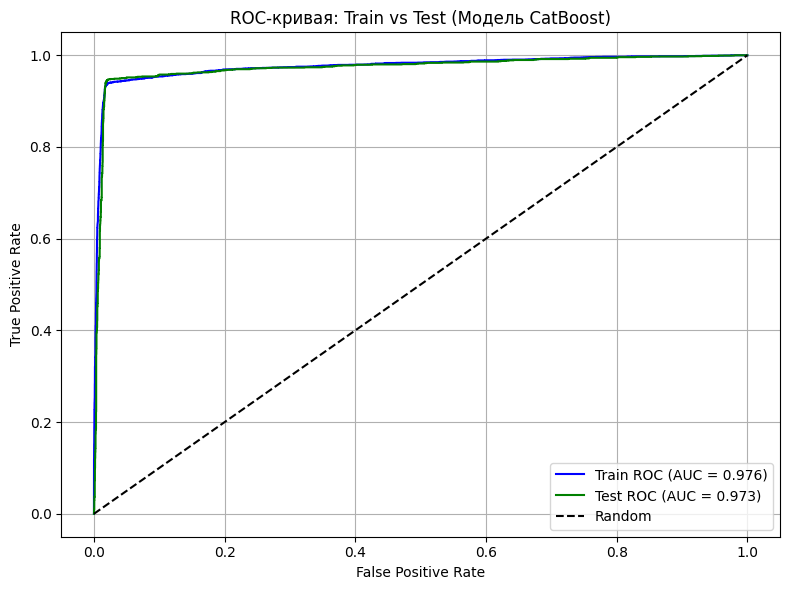

In [59]:
# ROC-кривая + AUC модели CatBoost
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_cb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_cb)

auc_train = roc_auc_score(y_train, y_train_proba_cb)
auc_test = roc_auc_score(y_test, y_test_proba_cb)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Модель CatBoost)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## <font color='blue' size='5'> **LightGBM**

In [60]:
# Определим целевую функцию для Optuna
def objective(trial):
    # Гиперпараметры для поиска
    num_leaves = trial.suggest_int('num_leaves', 50, 400)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 2.0)

    # Создание модели
    model_lgbm = lgb.LGBMClassifier(
        max_depth = max_depth,
        num_leaves = num_leaves,
        learning_rate = learning_rate,
        random_state=42
    )

    # Кросс-валидация
    score = cross_val_score(model_lgbm, X_train_p, y_train, cv=5, scoring='accuracy').mean()
    return score

# Создание Optuna study
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective, n_trials=50)

# Лучший результат
print("Лучший результат:")
trial_lgbm = study_lgbm.best_trial

print(f"  Accuracy: {trial_lgbm.value}")
best_params_lgbm = {}

print("Лучшие гиперпараметры:")
for key, value in trial_lgbm.params.items():
    best_params_lgbm[key] = value
    print(f"  {key}: {value}")

[I 2025-07-31 11:43:20,043] A new study created in memory with name: no-name-94a2c3f4-d71b-4d7c-b900-7aebdaad1ff9


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:30,056] Trial 0 finished with value: 0.9486347948824916 and parameters: {'num_leaves': 50, 'max_depth': 5, 'learning_rate': 1.045444965975546}. Best is trial 0 with value: 0.9486347948824916.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:30,754] Trial 1 finished with value: 0.9667592691431561 and parameters: {'num_leaves': 399, 'max_depth': 2, 'learning_rate': 0.9590969794524875}. Best is trial 1 with value: 0.9667592691431561.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:31,930] Trial 2 finished with value: 0.8833883467172308 and parameters: {'num_leaves': 183, 'max_depth': 4, 'learning_rate': 1.4964033082320793}. Best is trial 1 with value: 0.9667592691431561.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:33,088] Trial 3 finished with value: 0.9060623748000742 and parameters: {'num_leaves': 385, 'max_depth': 9, 'learning_rate': 1.663480528298885}. Best is trial 1 with value: 0.9667592691431561.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:33,986] Trial 4 finished with value: 0.8918690406916671 and parameters: {'num_leaves': 50, 'max_depth': 5, 'learning_rate': 1.8538372794732019}. Best is trial 1 with value: 0.9667592691431561.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:35,008] Trial 5 finished with value: 0.9680704321967601 and parameters: {'num_leaves': 261, 'max_depth': 2, 'learning_rate': 0.024461297164361483}. Best is trial 5 with value: 0.9680704321967601.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:38,361] Trial 6 finished with value: 0.8918798045030197 and parameters: {'num_leaves': 256, 'max_depth': 10, 'learning_rate': 1.1434586887936387}. Best is trial 5 with value: 0.9680704321967601.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:40,162] Trial 7 finished with value: 0.8555462024708597 and parameters: {'num_leaves': 109, 'max_depth': 4, 'learning_rate': 1.5219880242058237}. Best is trial 5 with value: 0.9680704321967601.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Info] Number of positive: 2701, number of negat

[I 2025-07-31 11:43:43,275] Trial 8 finished with value: 0.9644455551851985 and parameters: {'num_leaves': 199, 'max_depth': 8, 'learning_rate': 0.2345357279468045}. Best is trial 5 with value: 0.9680704321967601.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:45,738] Trial 9 finished with value: 0.844820123926555 and parameters: {'num_leaves': 335, 'max_depth': 10, 'learning_rate': 1.2351399530725875}. Best is trial 5 with value: 0.9680704321967601.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves 

[I 2025-07-31 11:43:46,416] Trial 10 finished with value: 0.9683017946722702 and parameters: {'num_leaves': 287, 'max_depth': 2, 'learning_rate': 0.14362932896378827}. Best is trial 10 with value: 0.9683017946722702.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:47,196] Trial 11 finished with value: 0.9669135900849242 and parameters: {'num_leaves': 286, 'max_depth': 2, 'learning_rate': 0.010457939037696007}. Best is trial 10 with value: 0.9683017946722702.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:48,037] Trial 12 finished with value: 0.9676848677166239 and parameters: {'num_leaves': 304, 'max_depth': 2, 'learning_rate': 0.49089596920424106}. Best is trial 10 with value: 0.9683017946722702.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:51,034] Trial 13 finished with value: 0.9588926773672432 and parameters: {'num_leaves': 241, 'max_depth': 7, 'learning_rate': 0.5523572850994553}. Best is trial 10 with value: 0.9683017946722702.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:52,561] Trial 14 finished with value: 0.9683789551431543 and parameters: {'num_leaves': 167, 'max_depth': 3, 'learning_rate': 0.02725836996794466}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:54,272] Trial 15 finished with value: 0.9638285092924102 and parameters: {'num_leaves': 149, 'max_depth': 4, 'learning_rate': 0.6103842695785489}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:43:55,768] Trial 16 finished with value: 0.9682247828728137 and parameters: {'num_leaves': 122, 'max_depth': 3, 'learning_rate': 0.3055308402454433}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:57,855] Trial 17 finished with value: 0.9550363189430294 and parameters: {'num_leaves': 201, 'max_depth': 6, 'learning_rate': 0.7806777078414919}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:43:59,027] Trial 18 finished with value: 0.9683789551431543 and parameters: {'num_leaves': 354, 'max_depth': 3, 'learning_rate': 0.24192242186740032}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:00,444] Trial 19 finished with value: 0.963057380332138 and parameters: {'num_leaves': 341, 'max_depth': 6, 'learning_rate': 0.35306618349061697}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:01,272] Trial 20 finished with value: 0.9652166841454708 and parameters: {'num_leaves': 163, 'max_depth': 3, 'learning_rate': 0.7558792549988992}. Best is trial 14 with value: 0.9683789551431543.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
Yo

[I 2025-07-31 11:44:02,603] Trial 21 finished with value: 0.9686874483552629 and parameters: {'num_leaves': 351, 'max_depth': 3, 'learning_rate': 0.1604165810655138}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:03,792] Trial 22 finished with value: 0.9674534160382573 and parameters: {'num_leaves': 361, 'max_depth': 3, 'learning_rate': 0.4015867378989375}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:05,662] Trial 23 finished with value: 0.9679932419915905 and parameters: {'num_leaves': 321, 'max_depth': 5, 'learning_rate': 0.16978222106397334}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:06,862] Trial 24 finished with value: 0.9685331868820658 and parameters: {'num_leaves': 362, 'max_depth': 3, 'learning_rate': 0.1365781054764529}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:08,227] Trial 25 finished with value: 0.9684560264111818 and parameters: {'num_leaves': 368, 'max_depth': 4, 'learning_rate': 0.039562810112523536}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:09,020] Trial 26 finished with value: 0.9625174949102335 and parameters: {'num_leaves': 377, 'max_depth': 4, 'learning_rate': 0.7078913311736921}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:11,279] Trial 27 finished with value: 0.9643683947143143 and parameters: {'num_leaves': 320, 'max_depth': 5, 'learning_rate': 0.43369997809057537}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:13,024] Trial 28 finished with value: 0.968070491665331 and parameters: {'num_leaves': 366, 'max_depth': 4, 'learning_rate': 0.1470252527359124}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002505 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-07-31 11:44:15,695] Trial 29 finished with value: 0.9438525405419549 and parameters: {'num_leaves': 399, 'max_depth': 6, 'learning_rate': 0.991087802478278}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:17,903] Trial 30 finished with value: 0.9667593583460125 and parameters: {'num_leaves': 283, 'max_depth': 5, 'learning_rate': 0.3154881686840787}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number 

[I 2025-07-31 11:44:19,714] Trial 31 finished with value: 0.9683789551431543 and parameters: {'num_leaves': 212, 'max_depth': 3, 'learning_rate': 0.028070624975532615}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:20,960] Trial 32 finished with value: 0.9686103176186643 and parameters: {'num_leaves': 343, 'max_depth': 3, 'learning_rate': 0.118278797922352}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:22,079] Trial 33 finished with value: 0.9681475926676442 and parameters: {'num_leaves': 321, 'max_depth': 4, 'learning_rate': 0.15701881854969452}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:22,712] Trial 34 finished with value: 0.9674534755068283 and parameters: {'num_leaves': 380, 'max_depth': 2, 'learning_rate': 0.6098985682161524}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:23,404] Trial 35 finished with value: 0.9679933311944471 and parameters: {'num_leaves': 345, 'max_depth': 3, 'learning_rate': 0.2716602688837937}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:25,109] Trial 36 finished with value: 0.9656796172364895 and parameters: {'num_leaves': 396, 'max_depth': 4, 'learning_rate': 0.4478618084911187}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:26,765] Trial 37 finished with value: 0.9679933014601616 and parameters: {'num_leaves': 303, 'max_depth': 5, 'learning_rate': 0.1484872955859171}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:27,846] Trial 38 finished with value: 0.9683017946722702 and parameters: {'num_leaves': 371, 'max_depth': 2, 'learning_rate': 0.13834598214056276}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:29,314] Trial 39 finished with value: 0.9657565993016606 and parameters: {'num_leaves': 335, 'max_depth': 3, 'learning_rate': 0.8484067747269092}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:30,624] Trial 40 finished with value: 0.8670346978297838 and parameters: {'num_leaves': 267, 'max_depth': 7, 'learning_rate': 1.3663929307336107}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:31,856] Trial 41 finished with value: 0.9677619389846515 and parameters: {'num_leaves': 233, 'max_depth': 3, 'learning_rate': 0.01036592715194301}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-07-31 11:44:33,678] Trial 42 finished with value: 0.834648916884049 and parameters: {'num_leaves': 89, 'max_depth': 4, 'learning_rate': 1.7976489142649488}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:35,109] Trial 43 finished with value: 0.9683789254088687 and parameters: {'num_leaves': 164, 'max_depth': 2, 'learning_rate': 0.09830080417779377}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-31 11:44:36,606] Trial 44 finished with value: 0.9684560561454673 and parameters: {'num_leaves': 352, 'max_depth': 3, 'learning_rate': 0.2557314569518158}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:37,289] Trial 45 finished with value: 0.9683789254088687 and parameters: {'num_leaves': 354, 'max_depth': 2, 'learning_rate': 0.23109784620022153}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:38,411] Trial 46 finished with value: 0.9672219346256051 and parameters: {'num_leaves': 385, 'max_depth': 4, 'learning_rate': 0.3709369079685365}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260413 -> initscore=-1.043825
[LightGBM] [Info] Start training from score -1.043825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:39,791] Trial 47 finished with value: 0.9625174949102338 and parameters: {'num_leaves': 307, 'max_depth': 3, 'learning_rate': 1.1339428290775002}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Info] Number of positive: 2701, number of negative: 7672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 10373, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260388 -> initscore=-1.043955
[LightGBM] [Info] Start training from score -1.043955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2025-07-31 11:44:43,278] Trial 48 finished with value: 0.9577357460525505 and parameters: {'num_leaves': 332, 'max_depth': 9, 'learning_rate': 0.5150276042166569}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 2701, number of negative: 7671
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 10372, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: p

[I 2025-07-31 11:44:44,590] Trial 49 finished with value: 0.9683789254088687 and parameters: {'num_leaves': 351, 'max_depth': 2, 'learning_rate': 0.2321435764815445}. Best is trial 21 with value: 0.9686874483552629.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [61]:
# Обучим модель с наилучшими праметрами

model_lgbm_best = lgb.LGBMClassifier(**best_params_lgbm)
model_lgbm_best.fit(X_train_p, y_train)

[LightGBM] [Info] Number of positive: 3377, number of negative: 9589
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 12966, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260450 -> initscore=-1.043629
[LightGBM] [Info] Start training from score -1.043629
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,boosting_type,'gbdt'
,num_leaves,351
,max_depth,3
,learning_rate,0.1604165810655138
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [62]:
# Получение вероятностей модели LightGBM
y_train_proba_lgb = model_lgbm_best.predict_proba(X_train_p)[:, 1]
y_test_proba_lgb = model_lgbm_best.predict_proba(X_test_p)[:, 1]
y_pred_lgb = model_lgbm_best.predict(X_test_p)

In [63]:
# Вычисление метрик модели LightGBM
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)

precision_lgb = precision_score(y_test, y_pred_lgb)

recall_lgb = recall_score(y_test, y_pred_lgb)

f1_lgb = f1_score(y_test, y_pred_lgb)

roc_auc_lgb = roc_auc_score(y_test, model_lgbm_best.predict_proba(X_test_p)[:, 1])


# Вывод результатов
print(f'Accuracy модели CatBoost: {accuracy_lgb}')

print(f'Precision модели CatBoost: {precision_lgb:.5f}')

print(f'Recall модели CatBoost: {recall_lgb:.5f}')

print(f'F1-score модели CatBoost: {f1_lgb:.5f}')

print(f'ROC-AUC модели CatBoost: {roc_auc_lgb:.5f}')

Accuracy модели CatBoost: 0.9710327455919395
Precision модели CatBoost: 0.94471
Recall модели CatBoost: 0.94406
F1-score модели CatBoost: 0.94439
ROC-AUC модели CatBoost: 0.97319


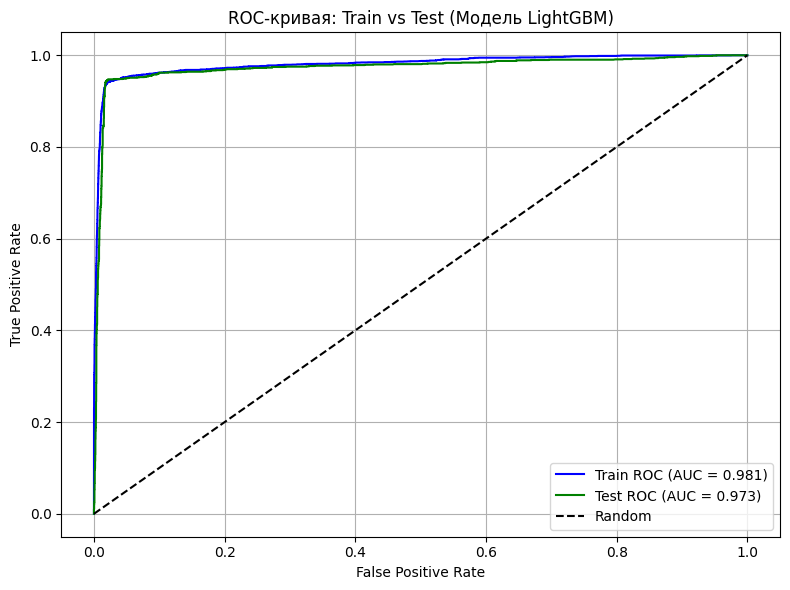

In [64]:
# ROC-кривая + AUC модели LightGBM
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_lgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_lgb)

auc_train = roc_auc_score(y_train, y_train_proba_lgb)
auc_test = roc_auc_score(y_test, y_test_proba_lgb)

# Построение ROC-графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая: Train vs Test (Модель LightGBM)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# <font color='#11a642' size='6'> **Вывод метрик всех моделей**

In [65]:
# Метрики логистической регрессии

print('Метрики логистической регрессии')

# Вывод результатов
print(f'Accuracy логистической регрессии: {accuracy_lr}')
print(f'Precision логистической регрессии: {precision_lr:.5f}')
print(f'Recall логистической регрессии: {recall_lr:.5f}')
print(f'F1-score логистической регрессии: {f1_lr:.5f}')
print(f'ROC-AUC логистической регрессии: {roc_auc_lr:.5f}')
print("-" * 50)

# Метрики дерева решений

print('Метрики дерева решений')

# Вывод результатов
print(f'Accuracy дерева решений: {accuracy_dt}')
print(f'Precision дерева решений: {precision_dt:.5f}')
print(f'Recall дерева решений: {recall_dt:.5f}')
print(f'F1-score дерева решений: {f1_dt:.5f}')
print(f'ROC-AUC дерева решений: {roc_auc_dt:.5f}')
print("-" * 50)

# Метрики random forest

print('Метрики модели Random Forest')

# Вывод результатов
print(f'Accuracy модели Random Forest: {accuracy_rf}')
print(f'Precision модели Random Forest: {precision_rf:.5f}')
print(f'Recall модели Random Forest: {recall_rf:.5f}')
print(f'F1-score модели Random Forest: {f1_rf:.5f}')
print(f'ROC-AUC модели Random Forest: {roc_auc_rf:.5f}')
print("-" * 50)

# Метрики модели XGBoost

print('Метрики модели XGBoost')

# Вывод результатов
print(f'Accuracy модели XGBoost: {accuracy_xgb}')
print(f'Precision модели XGBoost: {precision_xgb:.5}')
print(f'Recall модели XGBoost: {recall_xgb:.5f}')
print(f'F1-score модели XGBoost: {f1_xgb:.5f}')
print(f'ROC-AUC модели XGBoost: {roc_auc_xgb:.5f}')
print("-" * 50)

# Вывод результатов LightGBM
print(f'Accuracy модели LightGBM: {accuracy_lgb}')
print(f'Precision модели LightGBM: {precision_lgb:.5f}')
print(f'Recall модели LightGBM: {recall_lgb:.5f}')
print(f'F1-score модели LightGBM: {f1_lgb:.5f}')
print(f'ROC-AUC модели LightGBM: {roc_auc_lgb:.5f}')
print("-" * 50)

# Метрики модели CatBoost

print('Метрики модели CatBoost')

# Вывод результатов
print(f'Accuracy модели CatBoost: {accuracy_cb}')
print(f'Precision модели CatBoost: {precision_cb:.5f}')
print(f'Recall модели CatBoost: {recall_cb:.5f}')
print(f'F1-score модели CatBoost: {f1_cb:.5f}')
print(f'ROC-AUC модели CatBoost: {roc_auc_cb:.5f}')

Метрики логистической регрессии
Accuracy логистической регрессии: 0.9715725080964376
Precision логистической регрессии: 0.94730
Recall логистической регрессии: 0.94337
F1-score логистической регрессии: 0.94533
ROC-AUC логистической регрессии: 0.96070
--------------------------------------------------
Метрики дерева решений
Accuracy дерева решений: 0.9708528247571069
Precision дерева решений: 0.94653
Recall дерева решений: 0.94130
F1-score дерева решений: 0.94391
ROC-AUC дерева решений: 0.96062
--------------------------------------------------
Метрики модели Random Forest
Accuracy модели Random Forest: 0.9712126664267722
Precision модели Random Forest: 0.94475
Recall модели Random Forest: 0.94475
F1-score модели Random Forest: 0.94475
ROC-AUC модели Random Forest: 0.97123
--------------------------------------------------
Метрики модели XGBoost
Accuracy модели XGBoost: 0.9708528247571069
Precision модели XGBoost: 0.94406
Recall модели XGBoost: 0.94406
F1-score модели XGBoost: 0.94406
R

## <font color='blue' size='5'> **Вывод**

Исходя из метрик наилучшей моделью является модель CatBoost

# <font color='#11a642' size='6'> **Итерпретация результатов c помощью shap, permutation feature importance**

## <font color='blue' size='5'> **SHAP**

In [66]:
#%%time
explainer_tree = shap.Explainer(model_cb_best.predict, X_test_p)
shap_values_tree = explainer_tree(X_test_p)

ExactExplainer explainer: 5559it [07:19, 12.65it/s]                          



SHAP Global Summary Plot (Bar)...


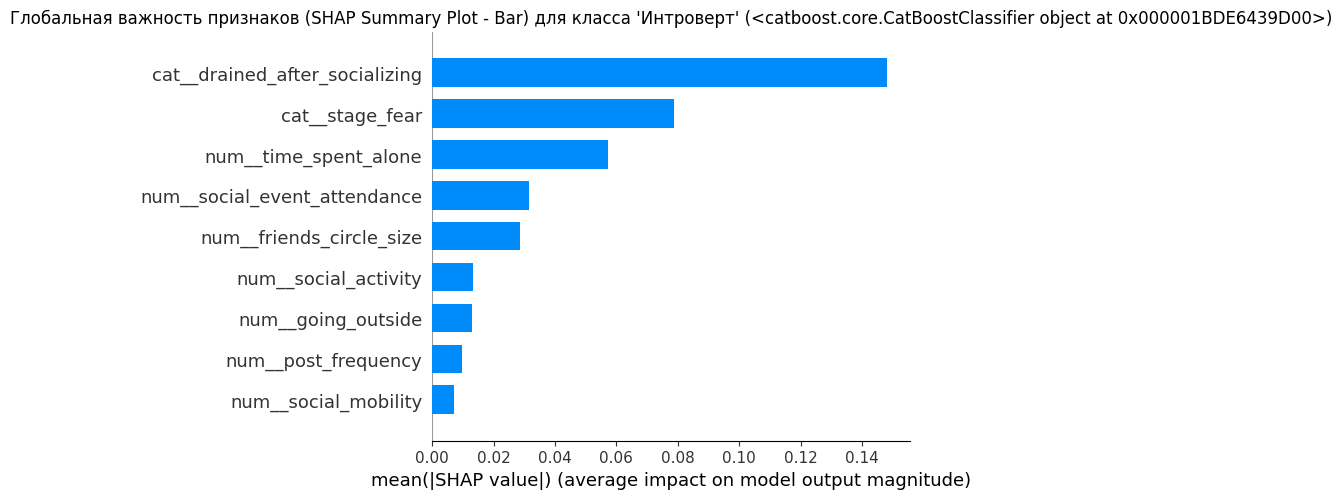

In [67]:
# SHAP Summary Plot (Bar) - Глобальная важность признаков
print("\nSHAP Global Summary Plot (Bar)...")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_tree, X_test_p, plot_type="bar", show=False)
plt.title(f"Глобальная важность признаков (SHAP Summary Plot - Bar) для класса 'Интроверт' ({model_cb_best})")
plt.tight_layout()
plt.show()

Как видно из графика, наиболее важным признаком является cat_drained_after_socializing


SHAP Global Summary Plot (Beeswarm)...


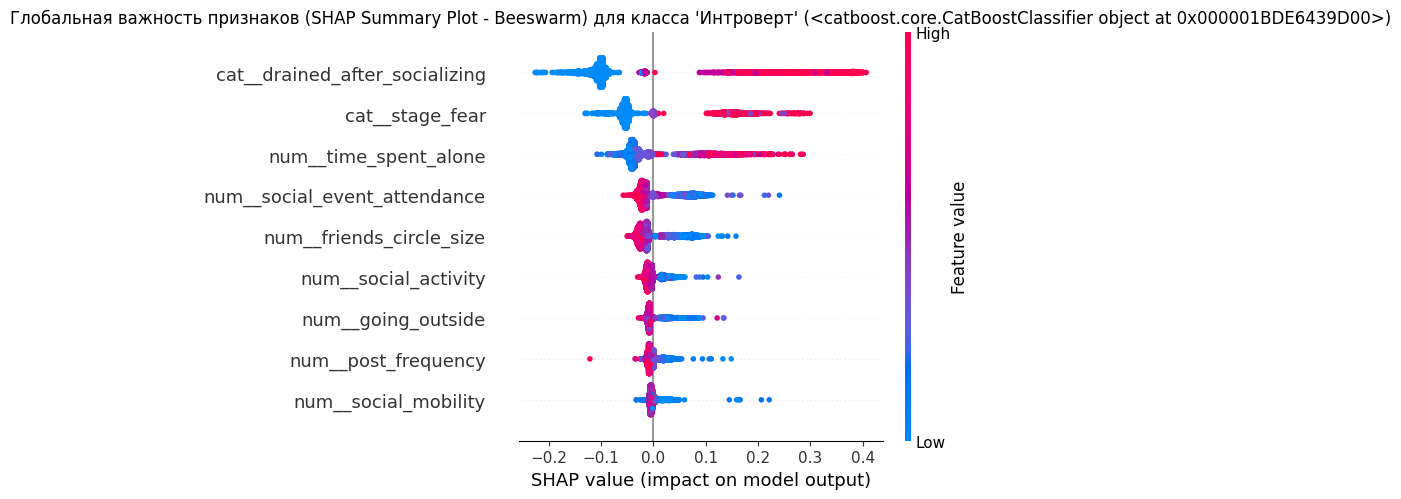

In [68]:
# SHAP Summary Plot (Beeswarm) - Глобальная важность признаков с распределением
print("\nSHAP Global Summary Plot (Beeswarm)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_tree, X_test_p, show=False)
plt.title(f"Глобальная важность признаков (SHAP Summary Plot - Beeswarm) для класса 'Интроверт' ({model_cb_best})")
plt.tight_layout() # ИСправлено: plt.layout() на plt.tight_layout()
plt.show()

На этом графике мы видим помимо важности признаков, ещи и направление их вляиния на результат работы модели

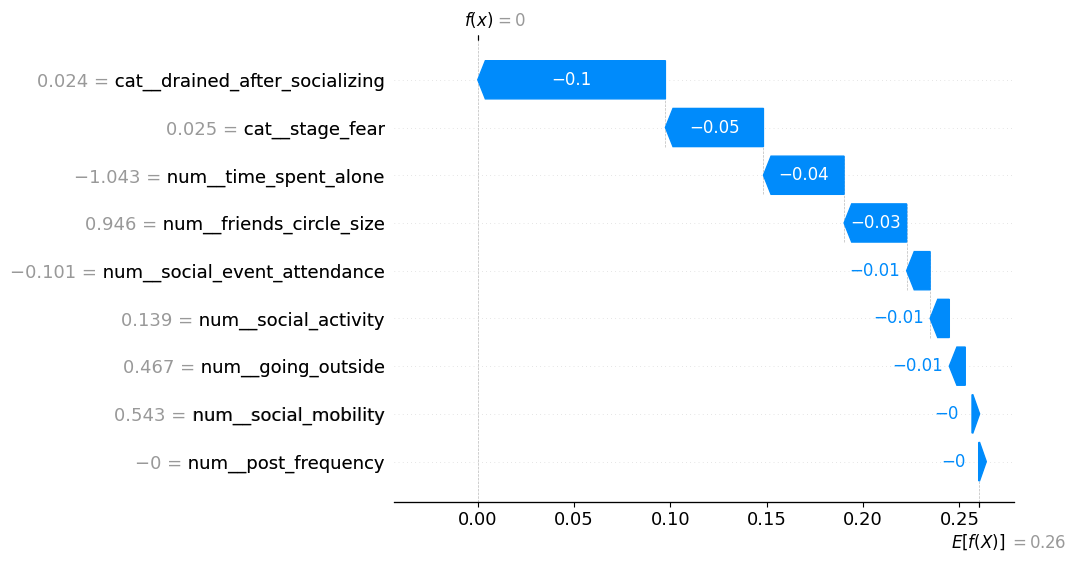

In [69]:
i = 1
shap.plots.waterfall(shap_values_tree[i], max_display=14)

Здесь мы видим влияние каждого признака на конкретного человека 

## <font color='blue' size='5'> **Permutation feature importance**

In [70]:

# n_jobs=-1 использует все доступные ядра CPU
result_perm_imp = permutation_importance(
    model_cb_best, X_test_p, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc'
)

In [71]:
# Получаем исходные имена признаков (до предобработки) для permutation_importance
original_feature_names = X.columns.tolist()

In [72]:
# Сортируем признаки по важности
sorted_idx_perm = result_perm_imp.importances_mean.argsort()[::-1]
sorted_features_perm = [original_feature_names[i] for i in sorted_idx_perm]
sorted_importances_perm = result_perm_imp.importances_mean[sorted_idx_perm]

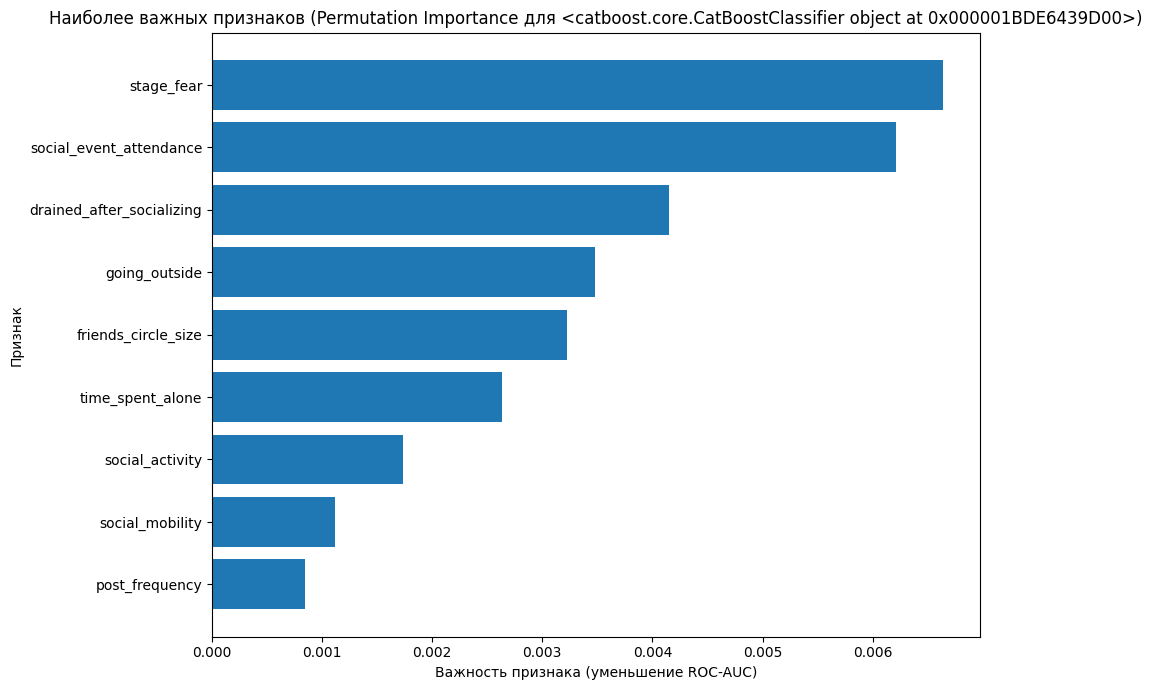

In [73]:
# Визуализация признаков

plt.figure(figsize=(10, 7))
plt.barh(sorted_features_perm, sorted_importances_perm)
plt.xlabel("Важность признака (уменьшение ROC-AUC)")
plt.ylabel("Признак")
plt.title(f"Наиболее важных признаков (Permutation Importance для {model_cb_best})")
plt.gca().invert_yaxis() # Переворачиваем ось Y для лучшей читаемости
plt.tight_layout()
plt.show()

Как видно из графика, на необработанных данных самым важным признаком является stage_fear

# <font color='#11a642' size='6'> **Участие в соревнованиях Kaggle**

На 20.07.2025 я занимаю 1265 место

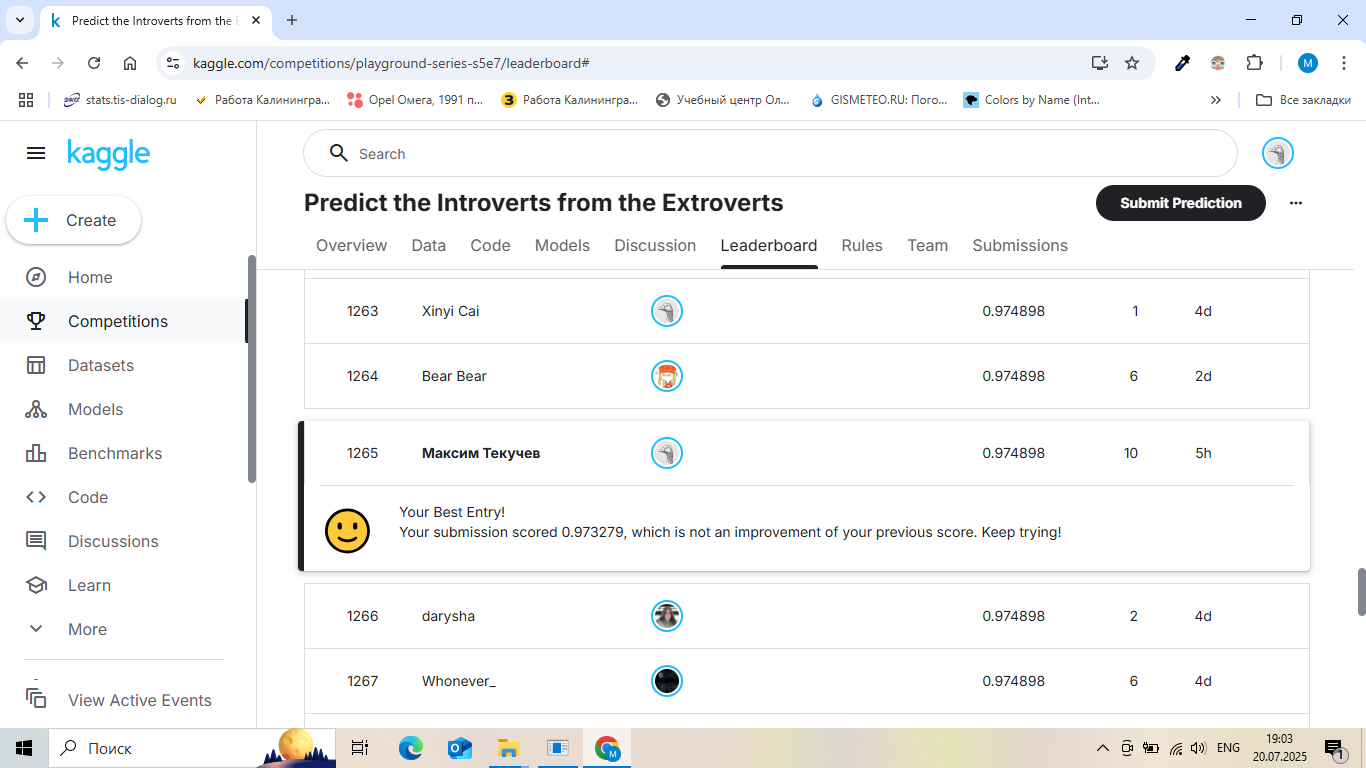

# <font color='#11a642' size='6'> **Выводы**

В данной работе основной целью было предсказать, является ли человек интровертом или экстравертом, учитывая его социальное поведение и черты характера. Для этой цели были загружены данные, проведен разведочный анализ данных, в ходе которого были исследованы пропуски, выбросы, числовые и категориальные признаки, добавлены несколько признаков, и определено, что это задача бинарной классификации. Для ее решения были обработаны заполнены и стандартизированы числовые и категориальные признаки. Было построено шесть моделей (Логистическая регрессия, дерево решений, модель Random forest, модель XGBoost, модель CatBoost и модель LigthGBM). На основе метрик, полученных в результате обучения каждой модели, было определено, что наилучшей моделью является модель CatBoost. Была произведене интерпретация результатов с помощью Permutation feature importance и SHAP. Также было принято участие в соревновании Kaggle. Таким образом, поставленная в данной работе задача, выполнена